# Non-Linear Principal Component Analysis (NLPCA) — Ground Motion Spectra
## NGA-Sub Subduction Zone Dataset

---

## What is NLPCA?

Standard (linear) PCA finds orthogonal axes of maximum variance — it is limited to linear manifolds.  
**NLPCA** (Kramer 1991) uses a **bottleneck autoencoder** to find a *nonlinear* low-dimensional manifold in the spectral space:

```
Spectra (108) → Encoder → Latent (k) → Decoder → Reconstructed Spectra (108)
                           [bottleneck]
```

- **Encoder**: compresses 108 spectral ordinates into k latent components
- **Latent space**: the NLPCA "scores" — analogous to PCA scores but on a curved manifold
- **Decoder**: reconstructs the full spectrum from the k components
- **Training**: minimize reconstruction MSE (input = target = spectra)

The key questions NLPCA answers in a GMM context:
1. How many components are needed to represent the spectral shape?
2. What physical variables control the latent axes?
3. How well does a low-dimensional representation reproduce recorded spectra?

---

## Cells Overview

| Cell | Content |
|------|---------|
| 1–5  | Data loading, preprocessing, normalization |
| 6    | NLPCA architecture (encoder → bottleneck → decoder) |
| 7    | Training: latent dims 1–8 + best single model |
| 8    | Training history plots |
| 9    | Performance metrics table |
| 10   | Graph 1 — Recorded vs Reconstructed spectra (4 samples) |
| 11   | Graph 2 — Multi-PC comparison on same records |
| 12   | Graph 3 — MSE boxplot vs number of PCs |
| 13   | Graph 4 — Scree plot (linear PCA baseline) |
| 14   | Graph 5 — Period-to-Period correlation contour |
| 15   | Graph 6 — Residual vs Magnitude |
| 16   | Graph 7 — Residual vs Rjb |
| 17   | Graph 8 — Residual vs Vs30 |
| 18   | Graph 9 — R² vs Period (by latent dim) |
| 19   | Graph 10 — Latent space visualization (colored by Mw, Rjb, Vs30, Region) |
| 20   | Graph 11 — Scatter: predicted vs recorded (log₁₀) |
| 21   | Graph 12 — Sigma of residuals vs Period |
| 22   | Graph 13 — Reconstruction error heatmap (Mw × Rjb grid) |
| 23   | Save models and final summary |


## Cell 1 — Imports & Setup

In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import matplotlib.ticker as ticker
import matplotlib.colors as mcolors
from matplotlib.gridspec import GridSpec
import seaborn as sns
import warnings, pickle, os
warnings.filterwarnings('ignore')

import tensorflow as tf
from tensorflow import keras
from tensorflow.keras import layers, callbacks
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler, MinMaxScaler
from sklearn.metrics import mean_squared_error, mean_absolute_error, r2_score
from sklearn.decomposition import PCA

np.random.seed(42)
tf.random.set_seed(42)

plt.rcParams.update({
    'font.size': 10, 'axes.titlesize': 11,
    'axes.labelsize': 10, 'figure.dpi': 120,
    'savefig.dpi': 150, 'savefig.bbox': 'tight',
})
print(f"TensorFlow : {tf.__version__}")
print("Setup complete.")


TensorFlow : 2.21.0
Setup complete.


## Cell 2 — Load & Inspect Dataset (Same Filtered NGA-Sub CSV)

In [2]:
CSV_PATH = 'NGAsub_flatfile_filtered.csv'
df = pd.read_csv(CSV_PATH)

print(f"Records  : {len(df)}")
print(f"Events   : {df['NGAsubEQID'].nunique()}")
print(f"Stations : {df['NGAsubSSN'].nunique()}")
print(f"Mw range : {df['Earthquake_Magnitude'].min():.1f} – {df['Earthquake_Magnitude'].max():.1f}")
print(f"Rjb range: {df['Rjb_km'].min():.1f} – {df['Rjb_km'].max():.1f} km")
print()
print("Region distribution:")
print(df['DatabaseRegion'].value_counts().to_string())


Records  : 8907
Events   : 188
Stations : 2894
Mw range : 4.1 – 9.1
Rjb range: 0.0 – 999.1 km

Region distribution:
DatabaseRegion
Japan                    5493
Taiwan                   1247
SouthAmerica              910
Alaska                    770
Cascadia                  381
CentralAmerica&Mexico     106


## Cell 3 — Define Columns & Derive Features

In [3]:
# ── Region metadata
REGION_MAP = {
    'Alaska': 1, 'Cascadia': 2, 'CentralAmerica&Mexico': 3,
    'Japan': 4, 'SouthAmerica': 5, 'Taiwan': 6,
}
REGION_NAMES  = {1:'AK', 2:'CAS', 3:'CAM', 4:'JP', 5:'SA', 6:'TW'}
REGION_COLORS = {1:'#1f77b4', 2:'#ff7f0e', 3:'#d62728',
                 4:'#9467bd', 5:'#17becf', 6:'#2ca02c'}

df['Region_Flag'] = df['DatabaseRegion'].map(REGION_MAP)
df['log_Rjb']  = np.log(df['Rjb_km'].clip(lower=0.01))
df['log_Vs30'] = np.log(df['Vs30_Selected_for_Analysis_m_s'])
df['FM']       = df['Intra_Inter_Flag'].map({0: 1, 1: 2, 5: 3}).fillna(4)

# ── 6 seismological input columns (used for residual analysis)
INPUT_COLS = ['Earthquake_Magnitude', 'Rjb_km', 'log_Rjb',
              'log_Vs30', 'Hypocenter_Depth_km', 'FM']

# ── 108 output targets (PSA + PGA + PGV + PGD) — same as BNN
PSA_COLS = [
    'T0pt010S','T0pt020S','T0pt022S','T0pt025S','T0pt029S',
    'T0pt030S','T0pt032S','T0pt035S','T0pt036S','T0pt040S',
    'T0pt042S','T0pt044S','T0pt045S','T0pt046S','T0pt048S',
    'T0pt050S','T0pt055S','T0pt060S','T0pt065S','T0pt067S',
    'T0pt070S','T0pt075S','T0pt080S','T0pt085S','T0pt090S',
    'T0pt095S','T0pt100S','T0pt110S','T0pt120S','T0pt130S',
    'T0pt133S','T0pt140S','T0pt150S','T0pt160S','T0pt170S',
    'T0pt180S','T0pt190S','T0pt200S','T0pt220S','T0pt240S',
    'T0pt250S','T0pt260S','T0pt280S','T0pt290S','T0pt300S',
    'T0pt320S','T0pt340S','T0pt350S','T0pt360S','T0pt380S',
    'T0pt400S','T0pt420S','T0pt440S','T0pt450S','T0pt460S',
    'T0pt480S','T0pt500S','T0pt550S','T0pt600S','T0pt650S',
    'T0pt667S','T0pt700S','T0pt750S','T0pt800S','T0pt850S',
    'T0pt900S','T0pt950S','T1pt000S','T1pt100S','T1pt200S',
    'T1pt300S','T1pt400S','T1pt500S','T1pt600S','T1pt700S',
    'T1pt800S','T1pt900S','T2pt000S','T2pt200S','T2pt400S',
    'T2pt500S','T2pt600S','T2pt800S','T3pt000S','T3pt200S',
    'T3pt400S','T3pt500S','T3pt600S','T3pt800S','T4pt000S',
    'T4pt200S','T4pt400S','T4pt600S','T4pt800S','T5pt000S',
    'T5pt500S','T6pt000S','T6pt500S','T7pt000S','T7pt500S',
    'T8pt000S','T8pt500S','T9pt000S','T9pt500S','T10pt000S',
]
PERIOD_VALUES = [
    0.01,0.02,0.022,0.025,0.029,0.03,0.032,0.035,0.036,0.04,
    0.042,0.044,0.045,0.046,0.048,0.05,0.055,0.06,0.065,0.067,
    0.07,0.075,0.08,0.085,0.09,0.095,0.1,0.11,0.12,0.13,
    0.133,0.14,0.15,0.16,0.17,0.18,0.19,0.2,0.22,0.24,
    0.25,0.26,0.28,0.29,0.3,0.32,0.34,0.35,0.36,0.38,
    0.4,0.42,0.44,0.45,0.46,0.48,0.5,0.55,0.6,0.65,
    0.667,0.7,0.75,0.8,0.85,0.9,0.95,1.0,1.1,1.2,
    1.3,1.4,1.5,1.6,1.7,1.8,1.9,2.0,2.2,2.4,
    2.5,2.6,2.8,3.0,3.2,3.4,3.5,3.6,3.8,4.0,
    4.2,4.4,4.6,4.8,5.0,5.5,6.0,6.5,7.0,7.5,
    8.0,8.5,9.0,9.5,10.0,
]
OUTPUT_COLS = PSA_COLS + ['PGA_g', 'PGV_cm_sec', 'PGD_cm']
ALL_PERIODS = PERIOD_VALUES + [0.0, -1.0, -2.0]   # 0=PGA, -1=PGV, -2=PGD

# NLPCA operates only on PSA (105 periods) — PGV and PGD have different units
# We use PSA (105) + PGA (1) = 106 spectral values for NLPCA
# (PGV and PGD are excluded — different physical units disrupt the autoencoder)
NLPCA_TARGET_COLS = PSA_COLS + ['PGA_g']   # 106 targets (all in g)
NLPCA_PERIODS     = np.array(PERIOD_VALUES + [0.0])   # 106 — 0.0 = PGA

print(f"NLPCA targets: {len(NLPCA_TARGET_COLS)} (PSA × 105 + PGA × 1)")


NLPCA targets: 106 (PSA × 105 + PGA × 1)


## Cell 4 — Filter, Log-Transform & Metadata

In [4]:
# Keep records with all-positive outputs
pos_mask = (df[NLPCA_TARGET_COLS] > 0).all(axis=1)
df_model = df[pos_mask].copy().reset_index(drop=True)
print(f"Records after filtering: {len(df_model)}")

# Metadata arrays (for residual analysis plots)
MW_ALL      = df_model['Earthquake_Magnitude'].values
RJB_ALL     = df_model['Rjb_km'].values
VS30_ALL    = df_model['Vs30_Selected_for_Analysis_m_s'].values
DEPTH_ALL   = df_model['Hypocenter_Depth_km'].values
REGION_IDS  = df_model['Region_Flag'].values.astype(int)
EVENT_IDS   = df_model['NGAsubEQID'].values.astype(int)
FM_ALL      = df_model['FM'].values

# Seismological inputs (for coloring latent space)
X_meta = df_model[INPUT_COLS].values.astype(np.float32)

# NLPCA input/output: log of spectra (natural log, same as BNN)
Y_log = np.log(df_model[NLPCA_TARGET_COLS].values).astype(np.float32)   # (n, 106)

print(f"Y_log shape: {Y_log.shape}")
print(f"Y_log range: [{Y_log.min():.3f}, {Y_log.max():.3f}] ln(g)")


Records after filtering: 8907
Y_log shape: (8907, 106)
Y_log range: [-18.678, 2.245] ln(g)


## Cell 5 — Train/Test Split & Normalization

**Important:** The scaler is fitted **only on the training set** and applied to the test set.  
This prevents data leakage — the reference notebook's original code fitted the scaler on the full dataset, which is incorrect.


In [5]:
idx_all = np.arange(len(Y_log))
idx_train, idx_test = train_test_split(idx_all, test_size=0.30, random_state=42)

Y_log_tr = Y_log[idx_train]
Y_log_te = Y_log[idx_test]

# Metadata splits
MW_tr    = MW_ALL[idx_train];    MW_te    = MW_ALL[idx_test]
RJB_tr   = RJB_ALL[idx_train];   RJB_te   = RJB_ALL[idx_test]
VS30_tr  = VS30_ALL[idx_train];  VS30_te  = VS30_ALL[idx_test]
DEPTH_tr = DEPTH_ALL[idx_train]; DEPTH_te = DEPTH_ALL[idx_test]
REG_te   = REGION_IDS[idx_test]; REG_tr   = REGION_IDS[idx_train]
FM_te    = FM_ALL[idx_test]

# Z-score normalization: fit ONLY on training set
y_scaler = StandardScaler()
Y_tr_s   = y_scaler.fit_transform(Y_log_tr).astype(np.float32)   # (n_tr, 106)
Y_te_s   = y_scaler.transform(Y_log_te).astype(np.float32)       # (n_te, 106)
Y_all_s  = y_scaler.transform(Y_log).astype(np.float32)          # (n, 106)

n_features = Y_tr_s.shape[1]   # 106

print(f"Training : {len(idx_train)} ({len(idx_train)/len(idx_all)*100:.1f}%)")
print(f"Testing  : {len(idx_test)} ({len(idx_test)/len(idx_all)*100:.1f}%)")
print(f"n_features (NLPCA input/output dim): {n_features}")
print(f"Y_tr_s range: [{Y_tr_s.min():.3f}, {Y_tr_s.max():.3f}]")

# NLPCA: input = output = scaled spectra
X_tr_nlpca = Y_tr_s.copy()
X_te_nlpca = Y_te_s.copy()


Training : 6234 (70.0%)
Testing  : 2673 (30.0%)
n_features (NLPCA input/output dim): 106
Y_tr_s range: [-4.880, 2.541]


## Cell 6 — NLPCA Architecture

```
Input (106)
    ↓
Dense(128, ELU)  — Encoder hidden 1
Dense(64, ELU)   — Encoder hidden 2
Dense(32, ELU)   — Encoder hidden 3
    ↓
Dense(k, Linear) — Latent / Bottleneck  (k = 1…8)
    ↓
Dense(32, ELU)   — Decoder hidden 1
Dense(64, ELU)   — Decoder hidden 2
Dense(128, ELU)  — Decoder hidden 3
    ↓
Dense(106, Linear) — Reconstructed spectra
```

ELU (Exponential Linear Unit) is used instead of ReLU to avoid dead neurons and provide smoother gradients, which is important for spectral reconstruction.


In [6]:
def build_nlpca(n_features, latent_dim, lr=0.001):
    """
    NLPCA autoencoder: 106 → [128→64→32] → k → [32→64→128] → 106
    ELU activations throughout; linear bottleneck and output.
    """
    # ── Encoder
    inp = keras.Input(shape=(n_features,), name='Input_Spectra')
    x   = layers.Dense(128, activation='elu', name='Enc1')(inp)
    x   = layers.Dense(64,  activation='elu', name='Enc2')(x)
    x   = layers.Dense(32,  activation='elu', name='Enc3')(x)
    latent = layers.Dense(latent_dim, activation='linear', name=f'Latent_{latent_dim}')(x)

    # ── Decoder
    x   = layers.Dense(32,  activation='elu', name='Dec1')(latent)
    x   = layers.Dense(64,  activation='elu', name='Dec2')(x)
    x   = layers.Dense(128, activation='elu', name='Dec3')(x)
    out = layers.Dense(n_features, activation='linear', name='Reconstructed')(x)

    autoencoder = keras.Model(inputs=inp, outputs=out, name=f'NLPCA_k{latent_dim}')
    encoder     = keras.Model(inputs=inp, outputs=latent, name=f'Encoder_k{latent_dim}')

    # Decoder sub-model
    lat_inp     = keras.Input(shape=(latent_dim,), name='Decoder_Input')
    dx = autoencoder.get_layer('Dec1')(lat_inp)
    dx = autoencoder.get_layer('Dec2')(dx)
    dx = autoencoder.get_layer('Dec3')(dx)
    dx = autoencoder.get_layer('Reconstructed')(dx)
    decoder = keras.Model(inputs=lat_inp, outputs=dx, name=f'Decoder_k{latent_dim}')

    autoencoder.compile(
        optimizer=keras.optimizers.Adam(learning_rate=lr),
        loss='mse', metrics=['mae']
    )
    return autoencoder, encoder, decoder


def inv_transform(Y_scaled, scaler):
    """Inverse-transform from normalized space → ln(g) → g."""
    Y_log  = scaler.inverse_transform(Y_scaled)
    Y_orig = np.exp(Y_log)
    return Y_orig, Y_log

# Build best single model (k=5) for detailed analysis
BEST_K = 5
ae_best, enc_best, dec_best = build_nlpca(n_features, BEST_K)
print("Best model (k=5) summary:")
ae_best.summary()


Best model (k=5) summary:


Model: "NLPCA_k5"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ Input_Spectra (InputLayer)      │ (None, 106)            │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ Enc1 (Dense)                    │ (None, 128)            │        13,696 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ Enc2 (Dense)                    │ (None, 64)             │         8,256 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ Enc3 (Dense)                    │ (None, 32)             │         2,080 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ Latent_5 (Dense)                │ (None, 5)              │           165 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ Dec1 (Dense)                    │ (None, 32)             │           192 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ Dec2 (Dense)                    │ (None, 64)             │         2,112 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ Dec3 (Dense)                    │ (None, 128)            │         8,320 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ Reconstructed (Dense)           │ (None, 106)            │        13,674 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 48,495 (189.43 KB)

 Trainable params: 48,495 (189.43 KB)

 Non-trainable params: 0 (0.00 B)

## Cell 7 — Train NLPCA for k = 1, 2, 3, 4, 5, 6, 7, 8

In [7]:
LATENT_DIMS = [1, 2, 3, 4, 5, 6, 7, 8]

nlpca_models   = {}   # autoencoder per k
nlpca_encoders = {}   # encoder per k
nlpca_decoders = {}   # decoder per k
nlpca_histories = {}  # training history per k

for k in LATENT_DIMS:
    print(f"\n── Training NLPCA k={k} ──")
    ae, enc, dec = build_nlpca(n_features, k, lr=0.001)

    es = callbacks.EarlyStopping(monitor='val_loss', patience=25,
                                  restore_best_weights=True, verbose=0)
    rlr = callbacks.ReduceLROnPlateau(monitor='val_loss', factor=0.5,
                                       patience=10, min_lr=1e-5, verbose=0)

    hist = ae.fit(
        X_tr_nlpca, X_tr_nlpca,
        validation_split=0.20,
        epochs=300, batch_size=64,
        callbacks=[es, rlr],
        verbose=0
    )
    nlpca_models[k]    = ae
    nlpca_encoders[k]  = enc
    nlpca_decoders[k]  = dec
    nlpca_histories[k] = hist

    # Quick metric
    recon_te = ae.predict(X_te_nlpca, verbose=0)
    mse_te   = mean_squared_error(X_te_nlpca.flatten(), recon_te.flatten())
    r2_te    = r2_score(X_te_nlpca.flatten(), recon_te.flatten())
    print(f"  k={k:2d}  epochs={len(hist.history['loss']):3d}  "
          f"val_loss={min(hist.history['val_loss']):.5f}  "
          f"test_MSE={mse_te:.5f}  test_R²={r2_te:.4f}")

# Assign best model
ae_best  = nlpca_models[BEST_K]
enc_best = nlpca_encoders[BEST_K]
dec_best = nlpca_decoders[BEST_K]

print(f"\n✓ All models trained. Best model = k={BEST_K}")



── Training NLPCA k=1 ──
  k= 1  epochs= 57  val_loss=0.07704  test_MSE=0.07600  test_R²=0.9215

── Training NLPCA k=2 ──
  k= 2  epochs=300  val_loss=0.01560  test_MSE=0.01583  test_R²=0.9837

── Training NLPCA k=3 ──
  k= 3  epochs=300  val_loss=0.00823  test_MSE=0.00849  test_R²=0.9912

── Training NLPCA k=4 ──
  k= 4  epochs=300  val_loss=0.00590  test_MSE=0.00595  test_R²=0.9939

── Training NLPCA k=5 ──
  k= 5  epochs=300  val_loss=0.00447  test_MSE=0.00455  test_R²=0.9953

── Training NLPCA k=6 ──
  k= 6  epochs=300  val_loss=0.00371  test_MSE=0.00369  test_R²=0.9962

── Training NLPCA k=7 ──
  k= 7  epochs=300  val_loss=0.00303  test_MSE=0.00301  test_R²=0.9969

── Training NLPCA k=8 ──
  k= 8  epochs=300  val_loss=0.00266  test_MSE=0.00262  test_R²=0.9973

✓ All models trained. Best model = k=5


## Cell 8 — Training History Plots

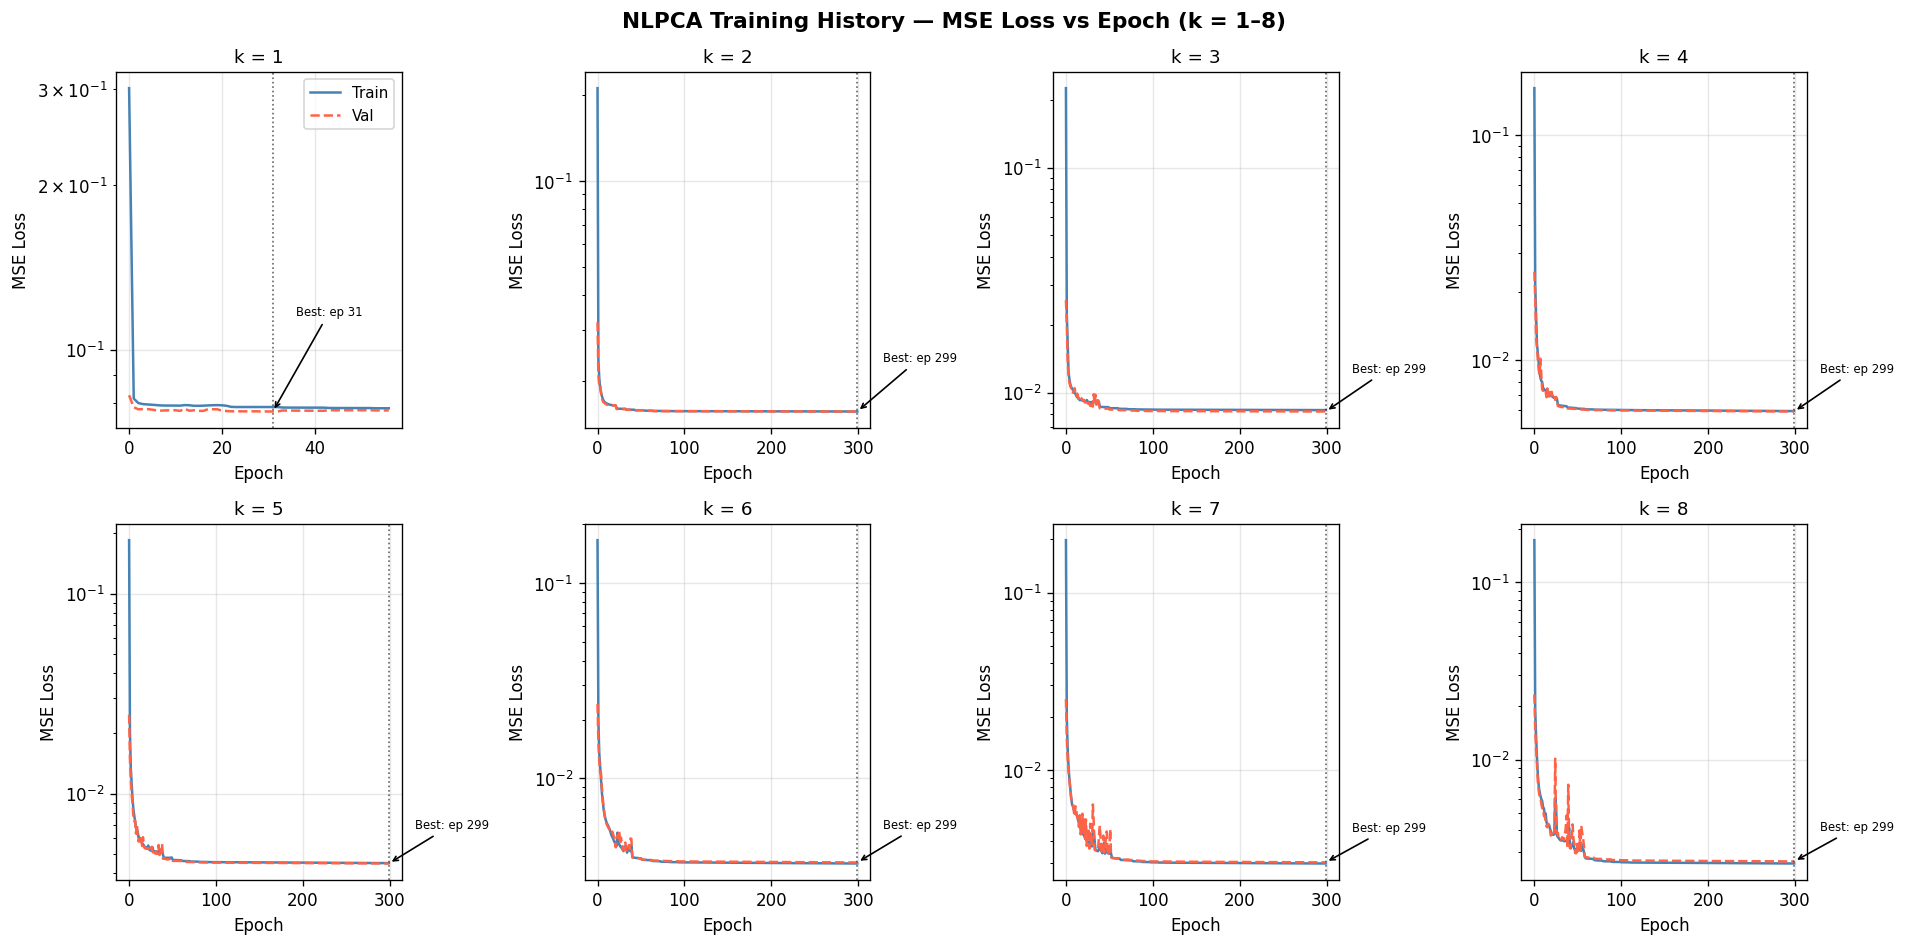

Saved: nlpca_fig_training_history.png


In [8]:
fig, axes = plt.subplots(2, 4, figsize=(16, 8))
fig.suptitle('NLPCA Training History — MSE Loss vs Epoch (k = 1–8)', fontsize=13, fontweight='bold')

for ax, k in zip(axes.flatten(), LATENT_DIMS):
    hist = nlpca_histories[k]
    ax.plot(hist.history['loss'],     lw=1.5, color='steelblue', label='Train')
    ax.plot(hist.history['val_loss'], lw=1.5, color='tomato', ls='--', label='Val')
    ax.set_title(f'k = {k}', fontsize=11)
    ax.set_xlabel('Epoch'); ax.set_ylabel('MSE Loss')
    ax.set_yscale('log'); ax.grid(alpha=0.3)
    if k == 1: ax.legend(fontsize=9)
    best_ep = np.argmin(hist.history['val_loss'])
    ax.axvline(best_ep, color='k', lw=1, ls=':', alpha=0.6)
    ax.annotate(f'Best: ep {best_ep}', xy=(best_ep, min(hist.history['val_loss'])),
                xytext=(best_ep + max(len(hist.history['loss'])//10, 2),
                        min(hist.history['val_loss'])*1.5),
                fontsize=7, arrowprops=dict(arrowstyle='->', color='k'))

plt.tight_layout()
plt.savefig('nlpca_fig_training_history.png')
plt.show()
print("Saved: nlpca_fig_training_history.png")


## Cell 9 — Performance Metrics Table (All k)

In [9]:
print("=" * 85)
print(f"{'k':>4} {'Val MSE':>10} {'Test MSE':>10} {'Test MAE':>10} {'Test R²':>10} {'RMSE_orig':>12}")
print("=" * 85)

rows = []
for k in LATENT_DIMS:
    ae   = nlpca_models[k]
    recon_te_s = ae.predict(X_te_nlpca, verbose=0)
    recon_tr_s = ae.predict(X_tr_nlpca, verbose=0)

    mse_te = mean_squared_error(X_te_nlpca.flatten(), recon_te_s.flatten())
    mae_te = mean_absolute_error(X_te_nlpca.flatten(), recon_te_s.flatten())
    r2_te  = r2_score(X_te_nlpca.flatten(), recon_te_s.flatten())
    val_mse = min(nlpca_histories[k].history['val_loss'])

    # RMSE in original (g) space
    y_te_orig, _ = inv_transform(X_te_nlpca, y_scaler)
    y_rec_orig, _ = inv_transform(recon_te_s, y_scaler)
    rmse_orig = np.sqrt(mean_squared_error(y_te_orig.flatten(), y_rec_orig.flatten()))

    print(f"{k:>4} {val_mse:>10.5f} {mse_te:>10.5f} {mae_te:>10.5f} {r2_te:>10.4f} {rmse_orig:>12.5f}")
    rows.append(dict(k=k, val_mse=round(val_mse,5), test_mse=round(mse_te,5),
                     test_mae=round(mae_te,5), test_r2=round(r2_te,4),
                     rmse_orig=round(rmse_orig,5)))

print("=" * 85)
import pandas as pd
df_perf = pd.DataFrame(rows)
df_perf.to_csv('nlpca_performance_table.csv', index=False)
print("\nSaved: nlpca_performance_table.csv")


   k    Val MSE   Test MSE   Test MAE    Test R²    RMSE_orig
   1    0.07704    0.07600    0.21362     0.9215      0.07688
   2    0.01560    0.01583    0.09289     0.9837      0.04773
   3    0.00823    0.00849    0.06813     0.9912      0.04026
   4    0.00590    0.00595    0.05742     0.9939      0.03558
   5    0.00447    0.00455    0.05022     0.9953      0.03154
   6    0.00371    0.00369    0.04538     0.9962      0.02846
   7    0.00303    0.00301    0.04105     0.9969      0.02525
   8    0.00266    0.00262    0.03837     0.9973      0.02420

Saved: nlpca_performance_table.csv


## Cell 10 — Graph 1: Recorded vs Reconstructed Spectra (k=5, 4 test samples)

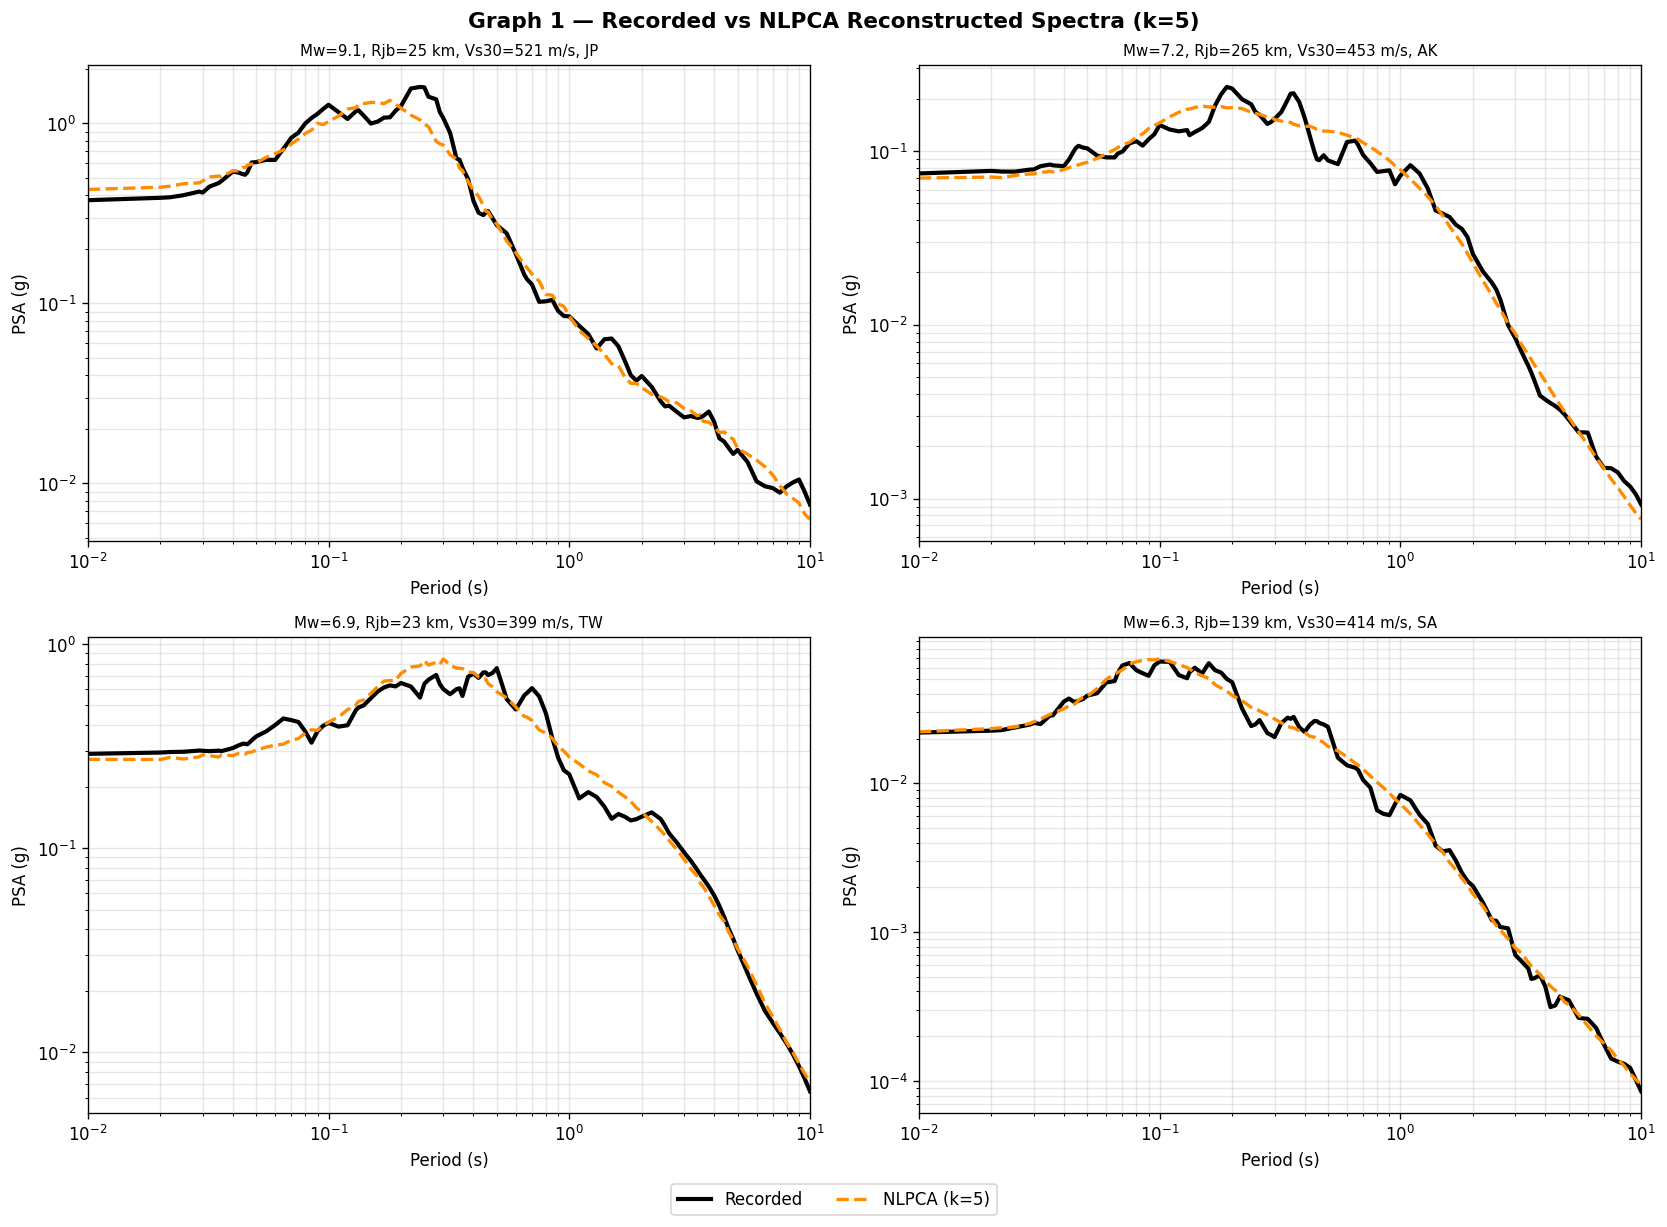

Saved: nlpca_fig1_recorded_vs_recon.png


In [10]:
recon_te_s_best = ae_best.predict(X_te_nlpca, verbose=0)
y_te_true_orig, y_te_true_log = inv_transform(X_te_nlpca, y_scaler)
y_te_recon_orig, y_te_recon_log = inv_transform(recon_te_s_best, y_scaler)

T_plot = NLPCA_PERIODS[:-1]   # PSA periods only (0.01–10s); skip PGA at index -1

# Pick 4 representative test records: near large, far large, near moderate, far moderate
def find_test_rec(mw_min, mw_max, rjb_min, rjb_max):
    mask = ((MW_te >= mw_min) & (MW_te < mw_max) &
            (RJB_te >= rjb_min) & (RJB_te < rjb_max))
    return int(np.where(mask)[0][0]) if mask.any() else 0

sample_idx = [
    find_test_rec(7.5, 9.5, 0,   100),
    find_test_rec(7.0, 8.5, 100, 400),
    find_test_rec(5.5, 7.0, 0,   100),
    find_test_rec(5.0, 6.5, 100, 400),
]

fig, axes = plt.subplots(2, 2, figsize=(14, 10))
fig.suptitle(f'Graph 1 — Recorded vs NLPCA Reconstructed Spectra (k={BEST_K})',
             fontsize=13, fontweight='bold')

for ax, idx in zip(axes.flatten(), sample_idx):
    # PSA values
    true_psa  = y_te_true_orig[idx, :-1]    # (105,) — exclude PGA index
    recon_psa = y_te_recon_orig[idx, :-1]

    ax.loglog(T_plot, true_psa,  color='black',      lw=2.5, label='Recorded')
    ax.loglog(T_plot, recon_psa, color='darkorange',  lw=2.0, ls='--', label=f'NLPCA (k={BEST_K})')

    mw_r   = MW_te[idx]; rjb_r  = RJB_te[idx]
    vs30_r = VS30_te[idx]; dep_r = DEPTH_te[idx]
    reg_r  = REGION_NAMES.get(REG_te[idx], '?')
    ax.set_title(f'Mw={mw_r:.1f}, Rjb={rjb_r:.0f} km, Vs30={vs30_r:.0f} m/s, {reg_r}', fontsize=9)
    ax.set_xlabel('Period (s)'); ax.set_ylabel('PSA (g)')
    ax.set_xlim(0.01, 10); ax.grid(True, which='both', alpha=0.3)

handles, labels = axes[0][0].get_legend_handles_labels()
fig.legend(handles, labels, loc='lower center', ncol=2, fontsize=10,
           bbox_to_anchor=(0.5, -0.03))
plt.tight_layout()
plt.savefig('nlpca_fig1_recorded_vs_recon.png', bbox_inches='tight')
plt.show()
print("Saved: nlpca_fig1_recorded_vs_recon.png")


## Cell 11 — Graph 2: Reconstructed Spectra Using Different Numbers of PCs

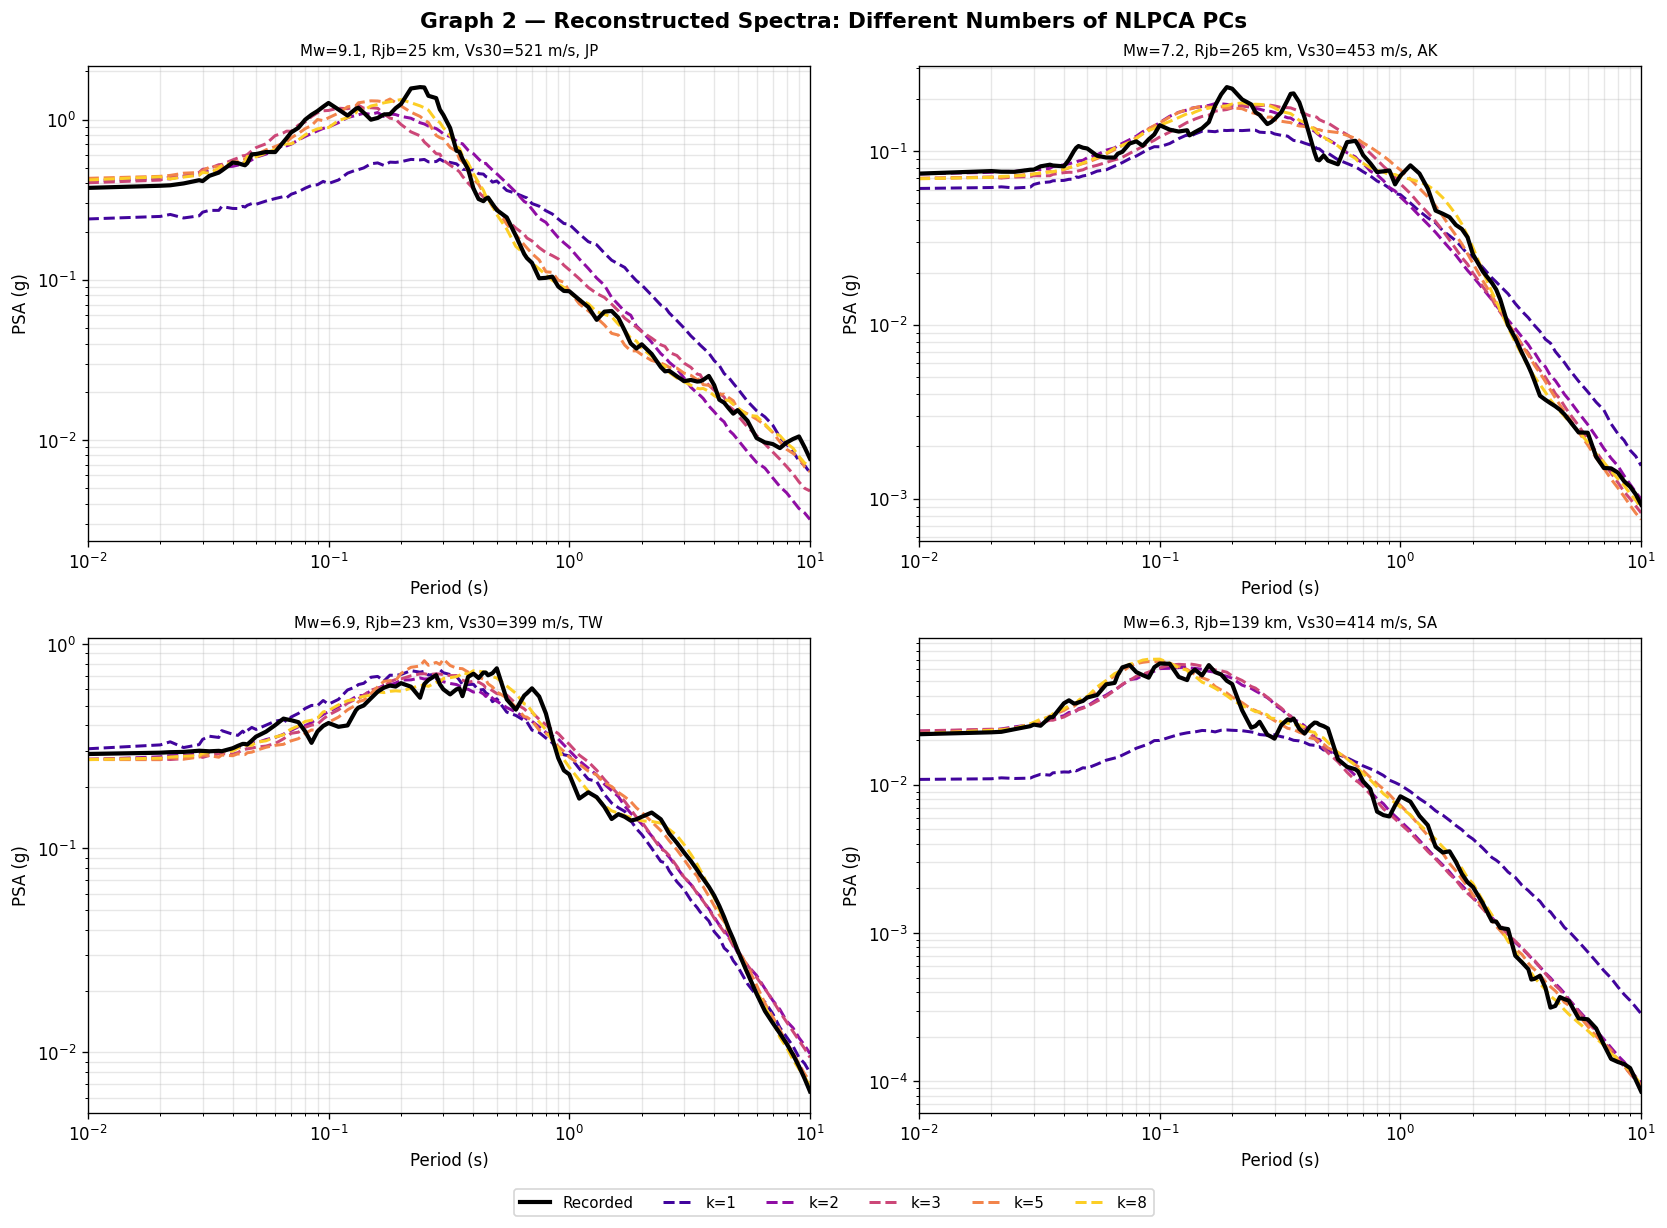

Saved: nlpca_fig2_multi_pc_comparison.png


In [11]:
compare_dims = [1, 2, 3, 5, 8]
cmap_d = plt.cm.plasma(np.linspace(0.1, 0.9, len(compare_dims)))
colors_d = {k: cmap_d[i] for i, k in enumerate(compare_dims)}

# Pre-compute reconstructions for each k
recon_dict = {}
for k in compare_dims:
    recon_s = nlpca_models[k].predict(X_te_nlpca, verbose=0)
    recon_dict[k], _ = inv_transform(recon_s, y_scaler)

fig, axes = plt.subplots(2, 2, figsize=(14, 10))
fig.suptitle('Graph 2 — Reconstructed Spectra: Different Numbers of NLPCA PCs',
             fontsize=13, fontweight='bold')

for ax, idx in zip(axes.flatten(), sample_idx):
    true_psa = y_te_true_orig[idx, :-1]
    ax.loglog(T_plot, true_psa, color='black', lw=2.5, label='Recorded', zorder=10)

    for k in compare_dims:
        rec_psa = recon_dict[k][idx, :-1]
        ax.loglog(T_plot, rec_psa, lw=1.8, ls='--',
                  color=colors_d[k], label=f'k={k}')

    mw_r = MW_te[idx]; rjb_r = RJB_te[idx]; vs30_r = VS30_te[idx]
    reg_r = REGION_NAMES.get(REG_te[idx], '?')
    ax.set_title(f'Mw={mw_r:.1f}, Rjb={rjb_r:.0f} km, Vs30={vs30_r:.0f} m/s, {reg_r}', fontsize=9)
    ax.set_xlabel('Period (s)'); ax.set_ylabel('PSA (g)')
    ax.set_xlim(0.01, 10); ax.grid(True, which='both', alpha=0.3)

handles, labels = axes[0][0].get_legend_handles_labels()
fig.legend(handles, labels, loc='lower center', ncol=len(compare_dims)+1, fontsize=9,
           bbox_to_anchor=(0.5, -0.03))
plt.tight_layout()
plt.savefig('nlpca_fig2_multi_pc_comparison.png', bbox_inches='tight')
plt.show()
print("Saved: nlpca_fig2_multi_pc_comparison.png")


## Cell 12 — Graph 3: Reconstruction MSE vs Number of PCs (Boxplot)

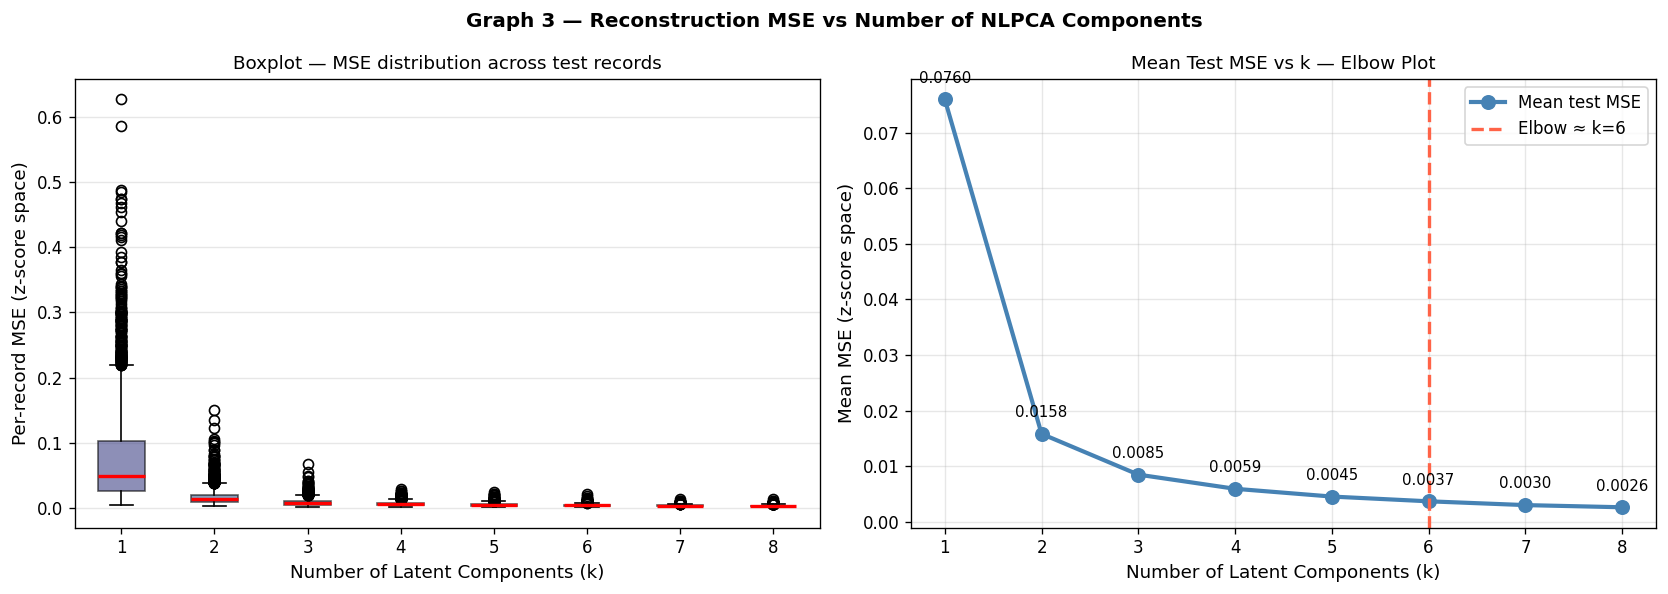

Saved: nlpca_fig3_mse_vs_pcs.png
Suggested optimal k (elbow): 6


In [12]:
# Per-record MSE in log space for each k
mse_per_rec = {}
for k in LATENT_DIMS:
    recon_s = nlpca_models[k].predict(X_te_nlpca, verbose=0)
    mse_per_rec[k] = np.mean((X_te_nlpca - recon_s)**2, axis=1)   # (n_te,)

mse_box_data = [mse_per_rec[k] for k in LATENT_DIMS]
mean_mse     = [np.mean(m) for m in mse_box_data]

fig, axes = plt.subplots(1, 2, figsize=(14, 5))
fig.suptitle('Graph 3 — Reconstruction MSE vs Number of NLPCA Components',
             fontsize=12, fontweight='bold')

ax = axes[0]
bp = ax.boxplot(mse_box_data, labels=LATENT_DIMS, notch=False, patch_artist=True,
                medianprops=dict(color='red', lw=2))
cmap_bp = plt.cm.viridis(np.linspace(0.2, 0.8, len(LATENT_DIMS)))
for patch, color in zip(bp['boxes'], cmap_bp):
    patch.set_facecolor(color); patch.set_alpha(0.6)
ax.set_xlabel('Number of Latent Components (k)', fontsize=11)
ax.set_ylabel('Per-record MSE (z-score space)', fontsize=11)
ax.set_title('Boxplot — MSE distribution across test records')
ax.grid(axis='y', alpha=0.3)

ax = axes[1]
ax.plot(LATENT_DIMS, mean_mse, 'o-', color='steelblue', lw=2.5, ms=8, label='Mean test MSE')
for k, m in zip(LATENT_DIMS, mean_mse):
    ax.annotate(f'{m:.4f}', (k, m), textcoords='offset points',
                xytext=(0, 10), ha='center', fontsize=9)
ax.set_xlabel('Number of Latent Components (k)', fontsize=11)
ax.set_ylabel('Mean MSE (z-score space)', fontsize=11)
ax.set_title('Mean Test MSE vs k — Elbow Plot')
ax.set_xticks(LATENT_DIMS); ax.grid(alpha=0.3)
ax.legend(fontsize=10)

# Mark the elbow
diffs = np.diff(mean_mse)
elbow_k = LATENT_DIMS[np.argmin(np.abs(np.diff(diffs))) + 1]
ax.axvline(elbow_k, color='tomato', ls='--', lw=2, label=f'Elbow ≈ k={elbow_k}')
ax.legend(fontsize=10)

plt.tight_layout()
plt.savefig('nlpca_fig3_mse_vs_pcs.png')
plt.show()
print("Saved: nlpca_fig3_mse_vs_pcs.png")
print(f"Suggested optimal k (elbow): {elbow_k}")


## Cell 13 — Graph 4: Scree Plot — Linear PCA Baseline

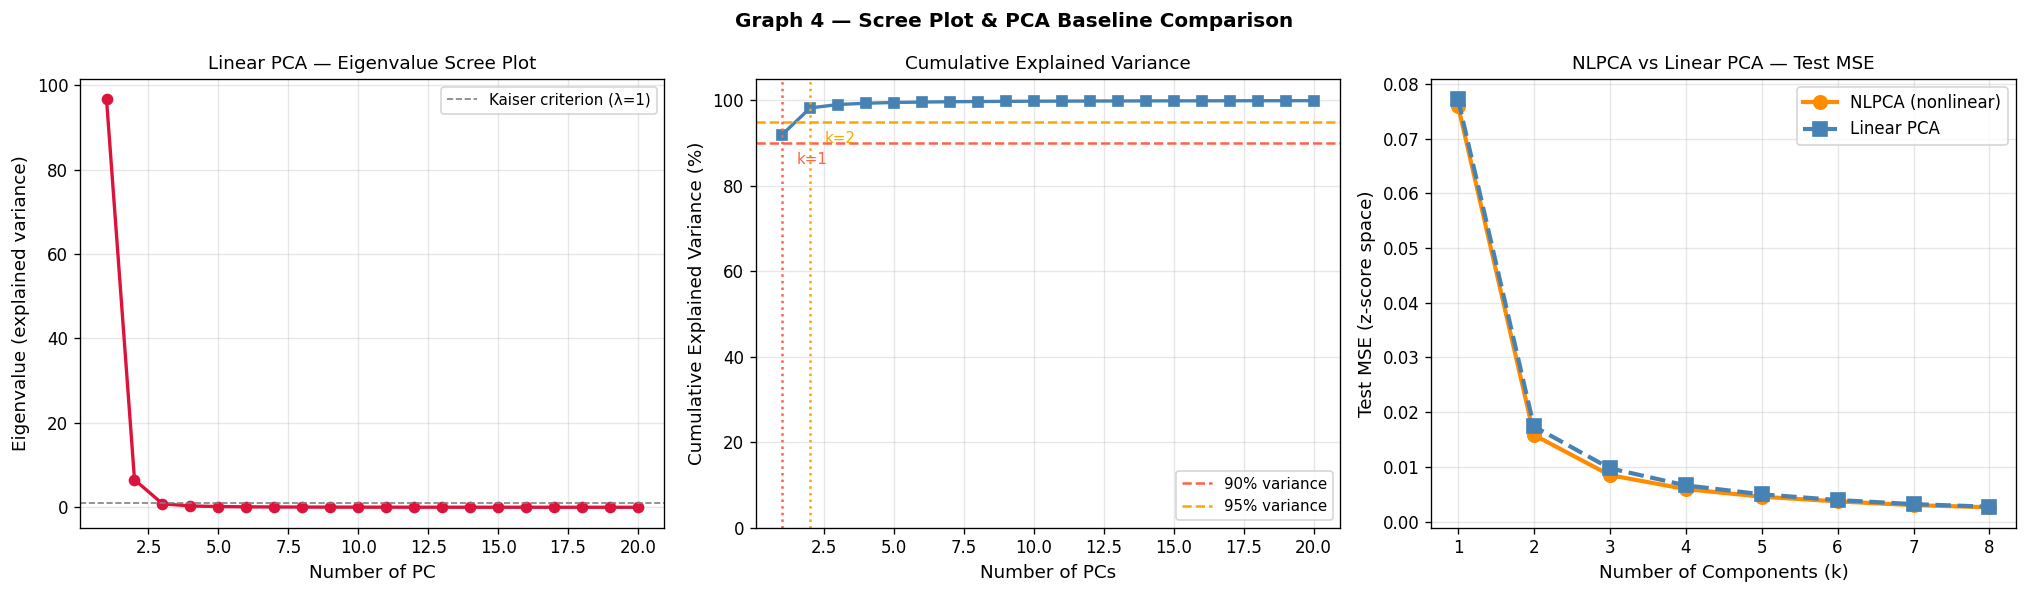

Saved: nlpca_fig4_scree_pca_comparison.png


In [13]:
# Linear PCA on full normalized spectra
pca_lin = PCA(n_components=min(20, n_features))
pca_lin.fit(Y_all_s)

pc_numbers   = np.arange(1, len(pca_lin.explained_variance_) + 1)
cum_var      = np.cumsum(pca_lin.explained_variance_ratio_) * 100

# Compare NLPCA vs linear PCA reconstruction MSE
nlpca_mean_mse = [np.mean(mse_per_rec[k]) for k in LATENT_DIMS]
# Linear PCA reconstruction MSE at each k
lpca_mse = []
for k in LATENT_DIMS:
    lpca = PCA(n_components=k)
    lpca.fit(Y_tr_s)
    recon_lpca = lpca.inverse_transform(lpca.transform(Y_te_s))
    lpca_mse.append(mean_squared_error(Y_te_s.flatten(), recon_lpca.flatten()))

fig, axes = plt.subplots(1, 3, figsize=(17, 5))
fig.suptitle('Graph 4 — Scree Plot & PCA Baseline Comparison', fontsize=12, fontweight='bold')

# Eigenvalue scree
ax = axes[0]
ax.plot(pc_numbers, pca_lin.explained_variance_, 'o-', color='crimson', lw=2, ms=6)
ax.set_xlabel('Number of PC', fontsize=11)
ax.set_ylabel('Eigenvalue (explained variance)', fontsize=11)
ax.set_title('Linear PCA — Eigenvalue Scree Plot')
ax.grid(alpha=0.3)
ax.axhline(1.0, color='gray', ls='--', lw=1, label='Kaiser criterion (λ=1)')
ax.legend(fontsize=9)

# Cumulative explained variance
ax = axes[1]
ax.plot(pc_numbers, cum_var, 's-', color='steelblue', lw=2, ms=6)
ax.axhline(90, color='tomato', ls='--', lw=1.5, label='90% variance')
ax.axhline(95, color='orange', ls='--', lw=1.5, label='95% variance')
for threshold, col in [(90, 'tomato'), (95, 'orange')]:
    k_thresh = int(np.searchsorted(cum_var, threshold)) + 1
    ax.axvline(k_thresh, color=col, ls=':', lw=1.5)
    ax.annotate(f'k={k_thresh}', xy=(k_thresh, threshold),
                xytext=(k_thresh+0.5, threshold-5), fontsize=9, color=col)
ax.set_xlabel('Number of PCs', fontsize=11)
ax.set_ylabel('Cumulative Explained Variance (%)', fontsize=11)
ax.set_title('Cumulative Explained Variance')
ax.set_ylim(0, 105); ax.grid(alpha=0.3); ax.legend(fontsize=9)

# NLPCA vs Linear PCA MSE
ax = axes[2]
ax.plot(LATENT_DIMS, nlpca_mean_mse, 'o-', color='darkorange', lw=2.5, ms=8, label='NLPCA (nonlinear)')
ax.plot(LATENT_DIMS, lpca_mse,       's--', color='steelblue',  lw=2.5, ms=8, label='Linear PCA')
ax.set_xlabel('Number of Components (k)', fontsize=11)
ax.set_ylabel('Test MSE (z-score space)', fontsize=11)
ax.set_title('NLPCA vs Linear PCA — Test MSE')
ax.set_xticks(LATENT_DIMS); ax.grid(alpha=0.3); ax.legend(fontsize=10)

plt.tight_layout()
plt.savefig('nlpca_fig4_scree_pca_comparison.png')
plt.show()
print("Saved: nlpca_fig4_scree_pca_comparison.png")


## Cell 14 — Graph 5: Period-to-Period Correlation Contour Map

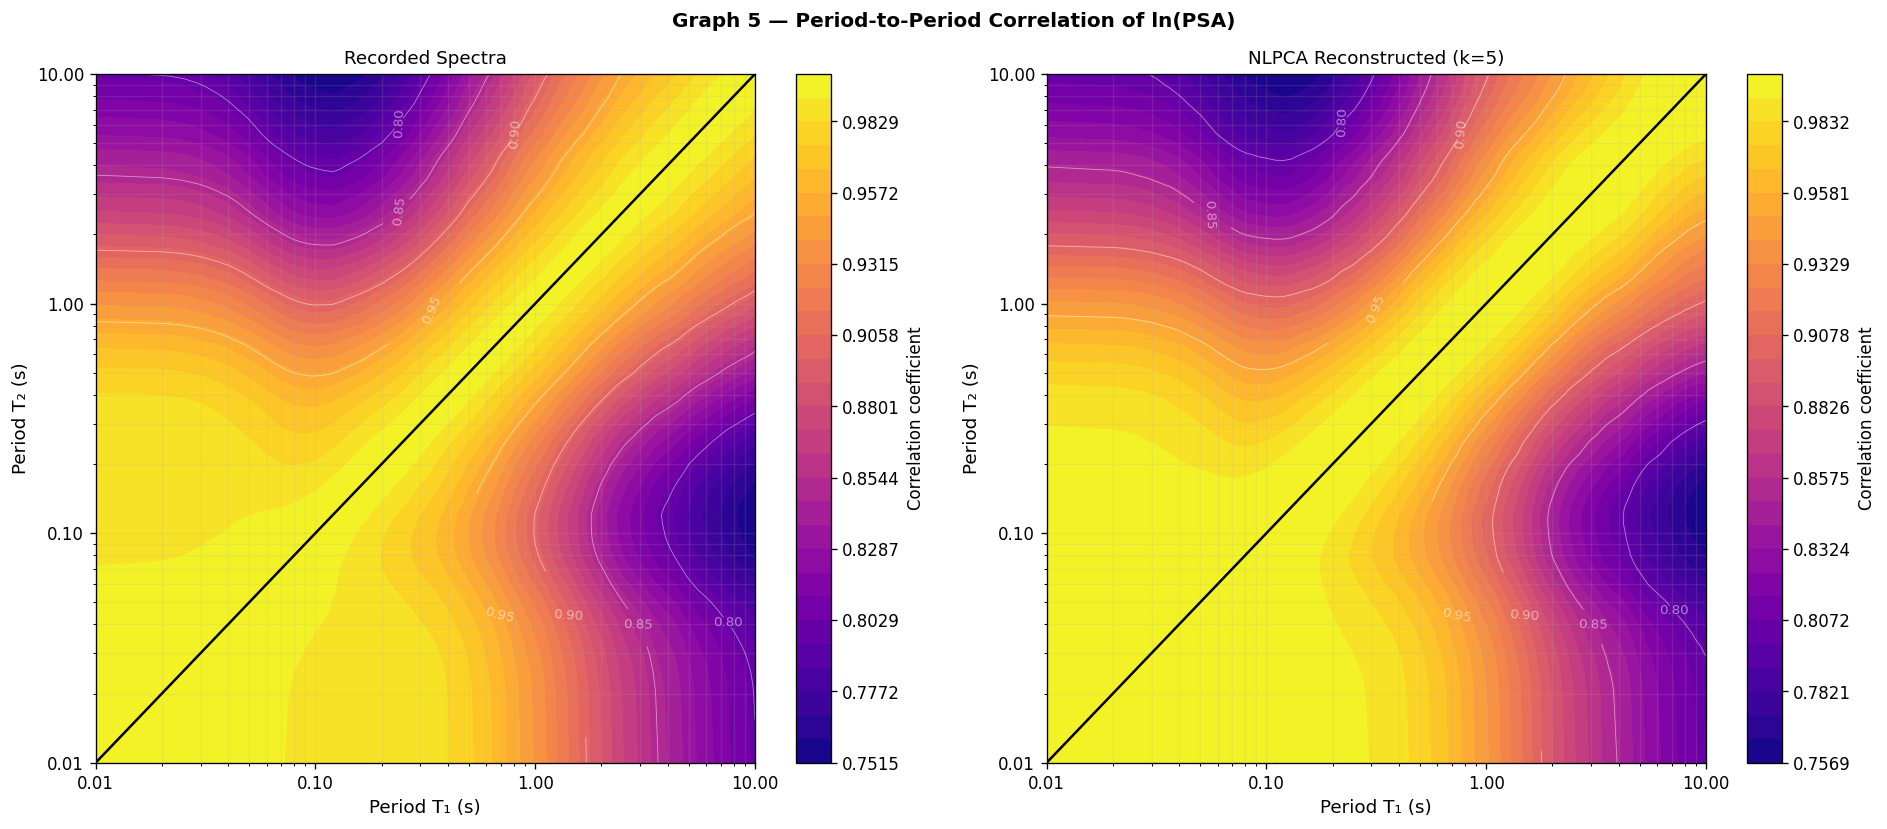

Saved: nlpca_fig5_period_correlation.png


In [14]:
# Use PSA only (105 periods, exclude PGA at index -1)
T_psa   = np.array(PERIOD_VALUES)        # (105,)
Y_psa   = Y_log[:, :-1]                  # (n, 105) — ln(PSA)

# Correlation of ln(PSA) across records — same as Baker & Jayaram 2008 framework
corr_mat = np.corrcoef(Y_psa.T)          # (105, 105)

fig, axes = plt.subplots(1, 2, figsize=(16, 7))
fig.suptitle('Graph 5 — Period-to-Period Correlation of ln(PSA)', fontsize=12, fontweight='bold')

# Raw NLPCA-reconstructed spectra correlation
recon_all_s = ae_best.predict(Y_all_s, verbose=0)
recon_all_log = y_scaler.inverse_transform(recon_all_s)
Y_recon_psa = recon_all_log[:, :-1]
corr_recon = np.corrcoef(Y_recon_psa.T)

for ax, corr, title in zip(axes, [corr_mat, corr_recon],
                            ['Recorded Spectra', f'NLPCA Reconstructed (k={BEST_K})']):
    Xg, Yg = np.meshgrid(T_psa, T_psa)
    levels = np.arange(0.4, 1.01, 0.05)
    cs = ax.contourf(Xg, Yg, corr, levels=np.linspace(corr.min(), 1.0, 30), cmap='plasma')
    cs2 = ax.contour(Xg, Yg, corr, levels=levels, colors='white', linewidths=0.5, alpha=0.5)
    ax.clabel(cs2, inline=True, fontsize=8, fmt='%.2f')
    plt.colorbar(cs, ax=ax, label='Correlation coefficient')
    ax.set_xscale('log'); ax.set_yscale('log')
    ax.set_xlabel('Period T₁ (s)', fontsize=11); ax.set_ylabel('Period T₂ (s)', fontsize=11)
    ax.set_title(f'{title}', fontsize=11)
    ax.grid(True, which='both', alpha=0.15)
    ax.plot([T_psa.min(), T_psa.max()], [T_psa.min(), T_psa.max()], 'k-', lw=1.5)
    ax.xaxis.set_major_formatter(ticker.ScalarFormatter())
    ax.yaxis.set_major_formatter(ticker.ScalarFormatter())

plt.tight_layout()
plt.savefig('nlpca_fig5_period_correlation.png')
plt.show()
print("Saved: nlpca_fig5_period_correlation.png")


## Cell 15 — Graph 6: Residual vs Magnitude

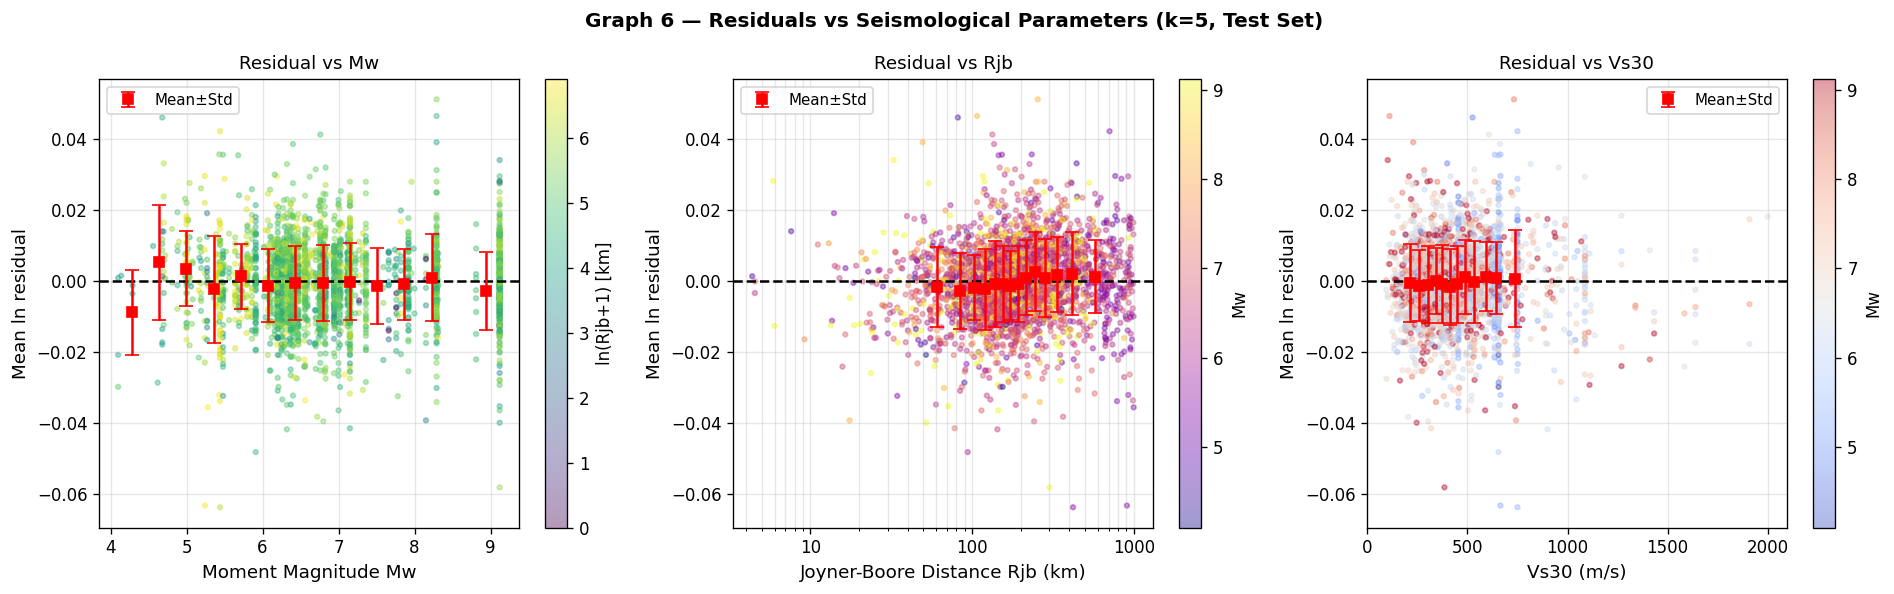

Saved: nlpca_fig6_residuals_seismo.png


In [15]:
def bin_stats(x, y, n_bins=12, pctile=False):
    edges = (np.percentile(x, np.linspace(5, 95, n_bins+1)) if pctile
             else np.linspace(x.min(), x.max(), n_bins+1))
    cx, cm, cs = [], [], []
    for lo, hi in zip(edges[:-1], edges[1:]):
        m = (x >= lo) & (x < hi)
        if m.sum() >= 3:
            cx.append((lo+hi)/2); cm.append(y[m].mean()); cs.append(y[m].std())
    return np.array(cx), np.array(cm), np.array(cs)

# Residual = mean over periods of (ln_true - ln_recon) per record
recon_te_s_best = ae_best.predict(X_te_nlpca, verbose=0)
recon_te_log    = y_scaler.inverse_transform(recon_te_s_best)
true_te_log     = y_scaler.inverse_transform(X_te_nlpca)
record_residual = np.mean(true_te_log - recon_te_log, axis=1)   # (n_te,) in ln space

fig, axes = plt.subplots(1, 3, figsize=(16, 5))
fig.suptitle(f'Graph 6 — Residuals vs Seismological Parameters (k={BEST_K}, Test Set)',
             fontsize=12, fontweight='bold')

# Panel A: vs Mw
ax = axes[0]
sc = ax.scatter(MW_te, record_residual, c=np.log(RJB_te+1), cmap='viridis',
                s=8, alpha=0.4, rasterized=True)
plt.colorbar(sc, ax=ax, label='ln(Rjb+1) [km]')
cx, cm, cs = bin_stats(MW_te, record_residual, n_bins=14, pctile=False)
ax.errorbar(cx, cm, yerr=cs, fmt='rs', ms=6, capsize=4, lw=1.5, zorder=5, label='Mean±Std')
ax.axhline(0, color='k', lw=1.5, ls='--')
ax.set_xlabel('Moment Magnitude Mw', fontsize=11); ax.set_ylabel('Mean ln residual', fontsize=11)
ax.set_title('Residual vs Mw'); ax.grid(alpha=0.3); ax.legend(fontsize=9)

# Panel B: vs Rjb
ax = axes[1]
sc = ax.scatter(RJB_te, record_residual, c=MW_te, cmap='plasma',
                s=8, alpha=0.4, rasterized=True)
plt.colorbar(sc, ax=ax, label='Mw')
cx, cm, cs = bin_stats(np.log(RJB_te+1), record_residual, n_bins=14, pctile=True)
rjb_bin_cents = np.exp(cx) - 1
ax.errorbar(rjb_bin_cents, cm, yerr=cs, fmt='rs', ms=6, capsize=4, lw=1.5, zorder=5, label='Mean±Std')
ax.axhline(0, color='k', lw=1.5, ls='--')
ax.set_xscale('log'); ax.set_xlabel('Joyner-Boore Distance Rjb (km)', fontsize=11)
ax.set_ylabel('Mean ln residual', fontsize=11)
ax.set_title('Residual vs Rjb'); ax.grid(True, which='both', alpha=0.3); ax.legend(fontsize=9)
ax.xaxis.set_major_formatter(ticker.ScalarFormatter())

# Panel C: vs Vs30
ax = axes[2]
sc = ax.scatter(VS30_te, record_residual, c=MW_te, cmap='coolwarm',
                s=8, alpha=0.4, rasterized=True)
plt.colorbar(sc, ax=ax, label='Mw')
cx, cm, cs = bin_stats(VS30_te, record_residual, n_bins=12, pctile=True)
ax.errorbar(cx, cm, yerr=cs, fmt='rs', ms=6, capsize=4, lw=1.5, zorder=5, label='Mean±Std')
ax.axhline(0, color='k', lw=1.5, ls='--')
ax.set_xlabel('Vs30 (m/s)', fontsize=11); ax.set_ylabel('Mean ln residual', fontsize=11)
ax.set_title('Residual vs Vs30'); ax.grid(alpha=0.3); ax.legend(fontsize=9)

plt.tight_layout()
plt.savefig('nlpca_fig6_residuals_seismo.png')
plt.show()
print("Saved: nlpca_fig6_residuals_seismo.png")


## Cell 16 — Graph 7: Residual by Tectonic Region

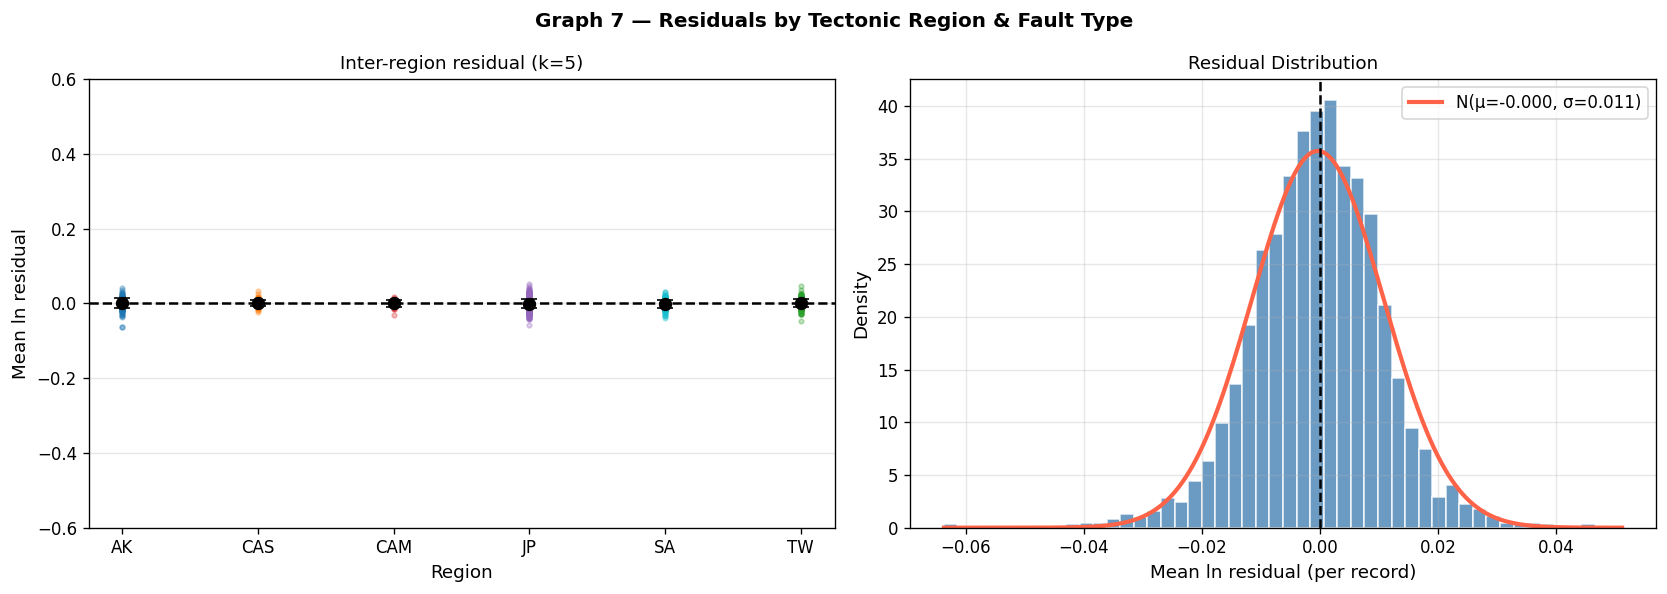

Saved: nlpca_fig7_residuals_region.png


In [16]:
fig, axes = plt.subplots(1, 2, figsize=(14, 5))
fig.suptitle('Graph 7 — Residuals by Tectonic Region & Fault Type', fontsize=12, fontweight='bold')

# Panel A: by region
ax = axes[0]
for rg_id, rg_name in REGION_NAMES.items():
    m = REG_te == rg_id
    if m.any():
        ax.scatter([rg_name]*m.sum(), record_residual[m], s=8, alpha=0.3,
                   color=REGION_COLORS[rg_id], rasterized=True)
        ax.errorbar(rg_name, record_residual[m].mean(), yerr=record_residual[m].std(),
                    fmt='o', color='k', ms=7, capsize=5, lw=2, zorder=5)
ax.axhline(0, color='k', lw=1.5, ls='--')
ax.set_xlabel('Region', fontsize=11); ax.set_ylabel('Mean ln residual', fontsize=11)
ax.set_title(f'Inter-region residual (k={BEST_K})'); ax.grid(axis='y', alpha=0.3)
ax.set_ylim(-0.6, 0.6)

# Panel B: residual distribution (histogram)
ax = axes[1]
ax.hist(record_residual, bins=50, color='steelblue', edgecolor='white', alpha=0.8, density=True)
from scipy import stats as sp_stats
mu_r, std_r = sp_stats.norm.fit(record_residual)
xn = np.linspace(record_residual.min(), record_residual.max(), 200)
ax.plot(xn, sp_stats.norm.pdf(xn, mu_r, std_r), color='tomato', lw=2.5,
        label=f'N(μ={mu_r:.3f}, σ={std_r:.3f})')
ax.axvline(0, color='k', lw=1.5, ls='--')
ax.set_xlabel('Mean ln residual (per record)', fontsize=11)
ax.set_ylabel('Density', fontsize=11)
ax.set_title('Residual Distribution'); ax.legend(fontsize=10); ax.grid(alpha=0.3)

plt.tight_layout()
plt.savefig('nlpca_fig7_residuals_region.png')
plt.show()
print("Saved: nlpca_fig7_residuals_region.png")


## Cell 17 — Graph 8: Sigma of Residuals vs Spectral Period (All k)

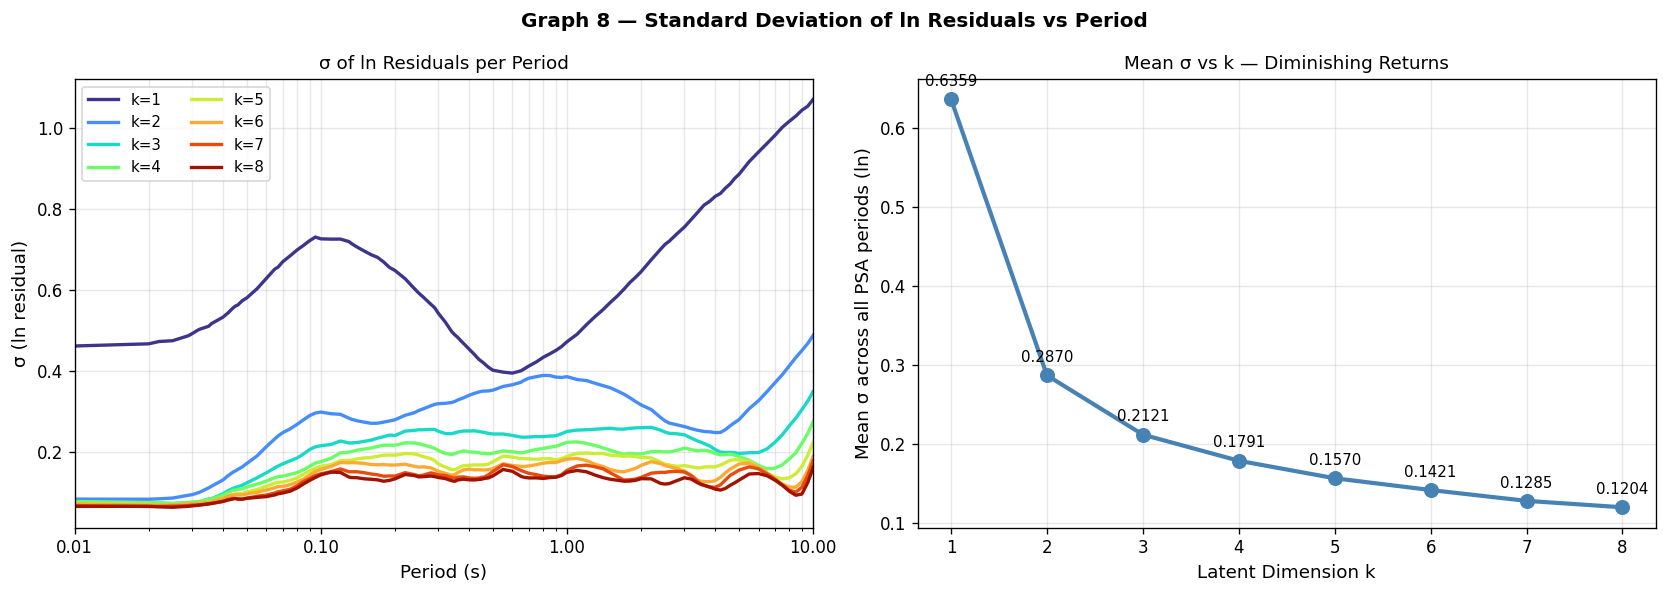

Saved: nlpca_fig8_sigma_vs_period.png


In [17]:
T_psa = np.array(PERIOD_VALUES)   # (105,) — PSA periods

fig, axes = plt.subplots(1, 2, figsize=(14, 5))
fig.suptitle('Graph 8 — Standard Deviation of ln Residuals vs Period', fontsize=12, fontweight='bold')

cmap_k = plt.cm.turbo(np.linspace(0.05, 0.95, len(LATENT_DIMS)))

ax = axes[0]
for k, col in zip(LATENT_DIMS, cmap_k):
    recon_s  = nlpca_models[k].predict(X_te_nlpca, verbose=0)
    recon_log = y_scaler.inverse_transform(recon_s)
    true_log  = y_scaler.inverse_transform(X_te_nlpca)
    delta_log = true_log - recon_log               # (n_te, 106)
    sigma_T   = delta_log[:, :-1].std(axis=0)      # (105,) — PSA only
    ax.semilogx(T_psa, sigma_T, lw=2.0, color=col, label=f'k={k}')

ax.set_xlabel('Period (s)', fontsize=11)
ax.set_ylabel('σ (ln residual)', fontsize=11)
ax.set_title('σ of ln Residuals per Period')
ax.legend(fontsize=9, ncol=2); ax.grid(True, which='both', alpha=0.3)
ax.set_xlim(0.01, 10)
ax.xaxis.set_major_formatter(ticker.ScalarFormatter())

# Right: mean σ across all periods vs k
ax = axes[1]
mean_sigma_k = []
for k in LATENT_DIMS:
    recon_s   = nlpca_models[k].predict(X_te_nlpca, verbose=0)
    recon_log = y_scaler.inverse_transform(recon_s)
    true_log  = y_scaler.inverse_transform(X_te_nlpca)
    delta_log = true_log - recon_log
    mean_sigma_k.append(delta_log[:, :-1].std(axis=0).mean())

ax.plot(LATENT_DIMS, mean_sigma_k, 'o-', lw=2.5, color='steelblue', ms=8)
for k, s in zip(LATENT_DIMS, mean_sigma_k):
    ax.annotate(f'{s:.4f}', (k, s), textcoords='offset points', xytext=(0, 8),
                ha='center', fontsize=9)
ax.set_xlabel('Latent Dimension k', fontsize=11)
ax.set_ylabel('Mean σ across all PSA periods (ln)', fontsize=11)
ax.set_title('Mean σ vs k — Diminishing Returns')
ax.set_xticks(LATENT_DIMS); ax.grid(alpha=0.3)

plt.tight_layout()
plt.savefig('nlpca_fig8_sigma_vs_period.png')
plt.show()
print("Saved: nlpca_fig8_sigma_vs_period.png")


## Cell 18 — Graph 9: R² vs Spectral Period (by Latent Dim)

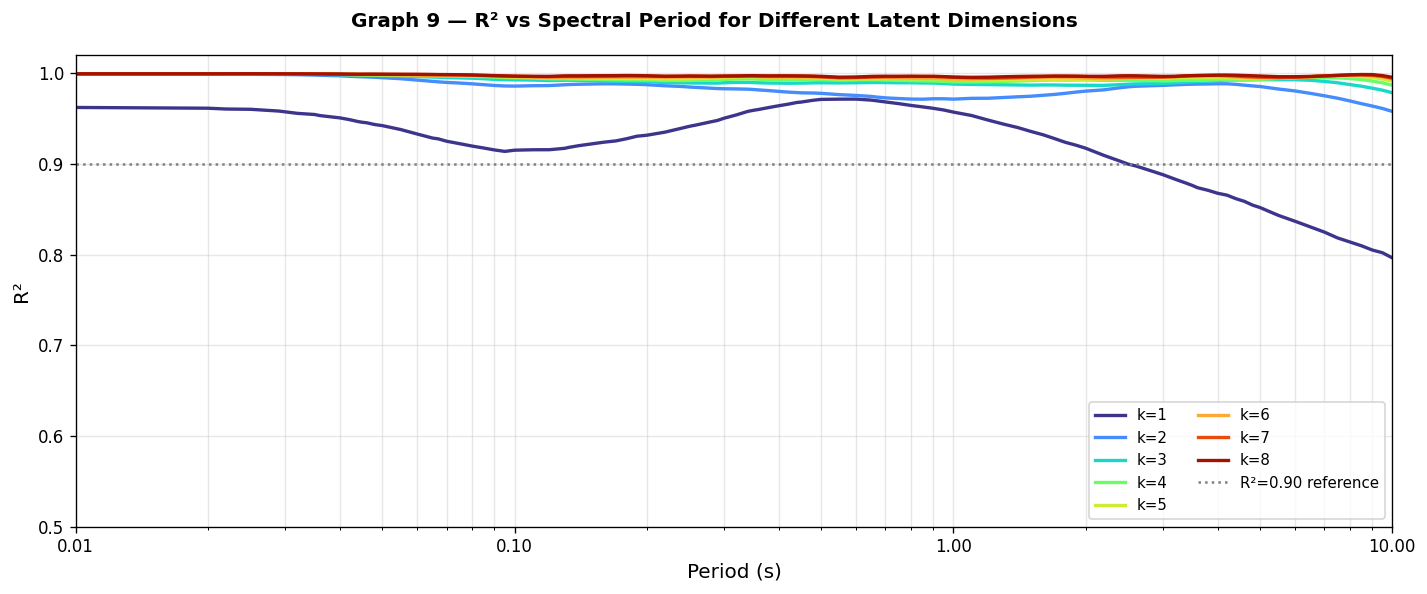

Saved: nlpca_fig9_r2_vs_period.png


In [18]:
fig, ax = plt.subplots(figsize=(12, 5))
fig.suptitle('Graph 9 — R² vs Spectral Period for Different Latent Dimensions',
             fontsize=12, fontweight='bold')

for k, col in zip(LATENT_DIMS, cmap_k):
    recon_s  = nlpca_models[k].predict(X_te_nlpca, verbose=0)
    recon_log = y_scaler.inverse_transform(recon_s)
    true_log  = y_scaler.inverse_transform(X_te_nlpca)

    r2_T = []
    for t in range(105):   # PSA periods only
        yt = true_log[:, t]; yp = recon_log[:, t]
        r2_T.append(r2_score(yt, yp))

    ax.semilogx(T_psa, r2_T, lw=2.0, color=col, label=f'k={k}')

ax.axhline(0.90, color='gray', ls=':', lw=1.5, label='R²=0.90 reference')
ax.set_xlabel('Period (s)', fontsize=12)
ax.set_ylabel('R²', fontsize=12)
ax.set_xlim(0.01, 10); ax.set_ylim(0.5, 1.02)
ax.legend(fontsize=9, ncol=2, loc='lower right')
ax.grid(True, which='both', alpha=0.3)
ax.xaxis.set_major_formatter(ticker.ScalarFormatter())

plt.tight_layout()
plt.savefig('nlpca_fig9_r2_vs_period.png')
plt.show()
print("Saved: nlpca_fig9_r2_vs_period.png")


## Cell 19 — Graph 10: Latent Space Visualization (k=5)

Latent space shape: (8907, 5)


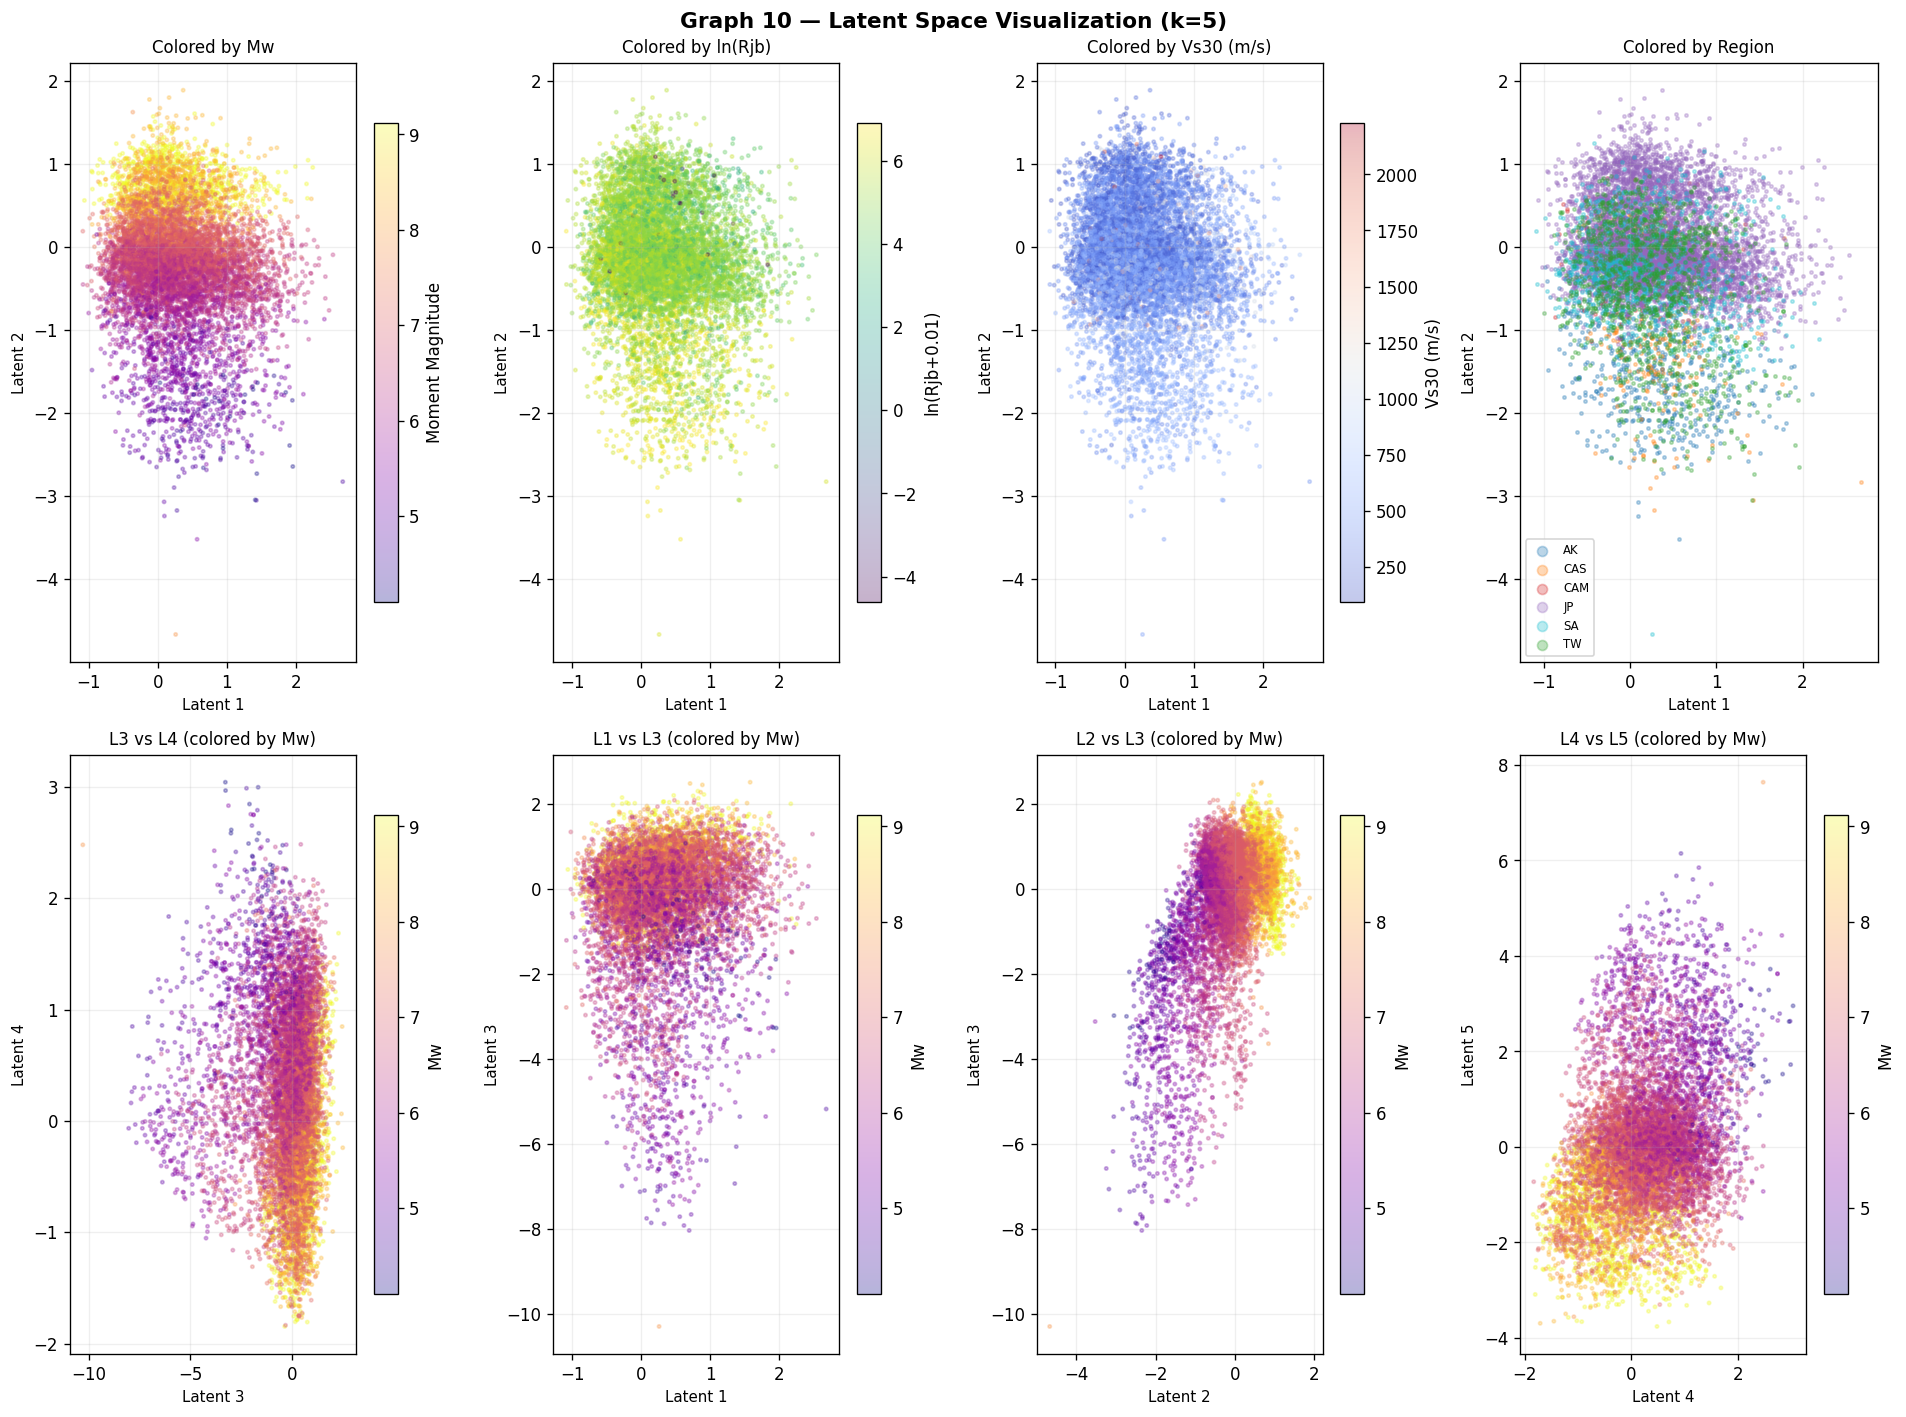

Saved: nlpca_fig10_latent_space.png


In [19]:
# Encode all records
latent_all = enc_best.predict(Y_all_s, verbose=0)   # (n, 5)
print(f"Latent space shape: {latent_all.shape}")

fig = plt.figure(figsize=(16, 12))
fig.suptitle(f'Graph 10 — Latent Space Visualization (k={BEST_K})', fontsize=13, fontweight='bold')

# Color variables
color_vars = [
    (MW_ALL,    'Mw',         'plasma',  'Moment Magnitude'),
    (np.log(RJB_ALL+0.01), 'ln(Rjb)', 'viridis', 'ln(Rjb+0.01)'),
    (VS30_ALL,  'Vs30 (m/s)', 'coolwarm','Vs30 (m/s)'),
    (REGION_IDS,'Region',     None,       'Tectonic Region'),
]

for plot_i, (color_vals, cname, cmap_name, ctitle) in enumerate(color_vars):
    ax = fig.add_subplot(2, 4, plot_i + 1)

    if cmap_name is None:
        # Discrete region coloring
        for rg_id, rg_name in REGION_NAMES.items():
            m = REGION_IDS == rg_id
            ax.scatter(latent_all[m, 0], latent_all[m, 1],
                       s=4, alpha=0.3, color=REGION_COLORS[rg_id],
                       label=rg_name, rasterized=True)
        ax.legend(fontsize=7, markerscale=3, loc='best')
    else:
        sc = ax.scatter(latent_all[:, 0], latent_all[:, 1],
                        c=color_vals, cmap=cmap_name, s=4, alpha=0.3, rasterized=True)
        plt.colorbar(sc, ax=ax, label=ctitle, shrink=0.8)

    ax.set_xlabel('Latent 1', fontsize=9); ax.set_ylabel('Latent 2', fontsize=9)
    ax.set_title(f'Colored by {cname}', fontsize=10); ax.grid(alpha=0.2)

# Latent 3 vs 4 colored by Mw
for plot_i, (l1, l2) in enumerate([(2,3), (0,2), (1,2), (3,4)]):
    ax = fig.add_subplot(2, 4, plot_i + 5)
    sc = ax.scatter(latent_all[:, l1], latent_all[:, l2],
                    c=MW_ALL, cmap='plasma', s=4, alpha=0.3, rasterized=True)
    plt.colorbar(sc, ax=ax, label='Mw', shrink=0.8)
    ax.set_xlabel(f'Latent {l1+1}', fontsize=9); ax.set_ylabel(f'Latent {l2+1}', fontsize=9)
    ax.set_title(f'L{l1+1} vs L{l2+1} (colored by Mw)', fontsize=10); ax.grid(alpha=0.2)

plt.tight_layout()
plt.savefig('nlpca_fig10_latent_space.png')
plt.show()
print("Saved: nlpca_fig10_latent_space.png")


## Cell 20 — Graph 11: Scatter — Predicted vs Recorded (log₁₀)

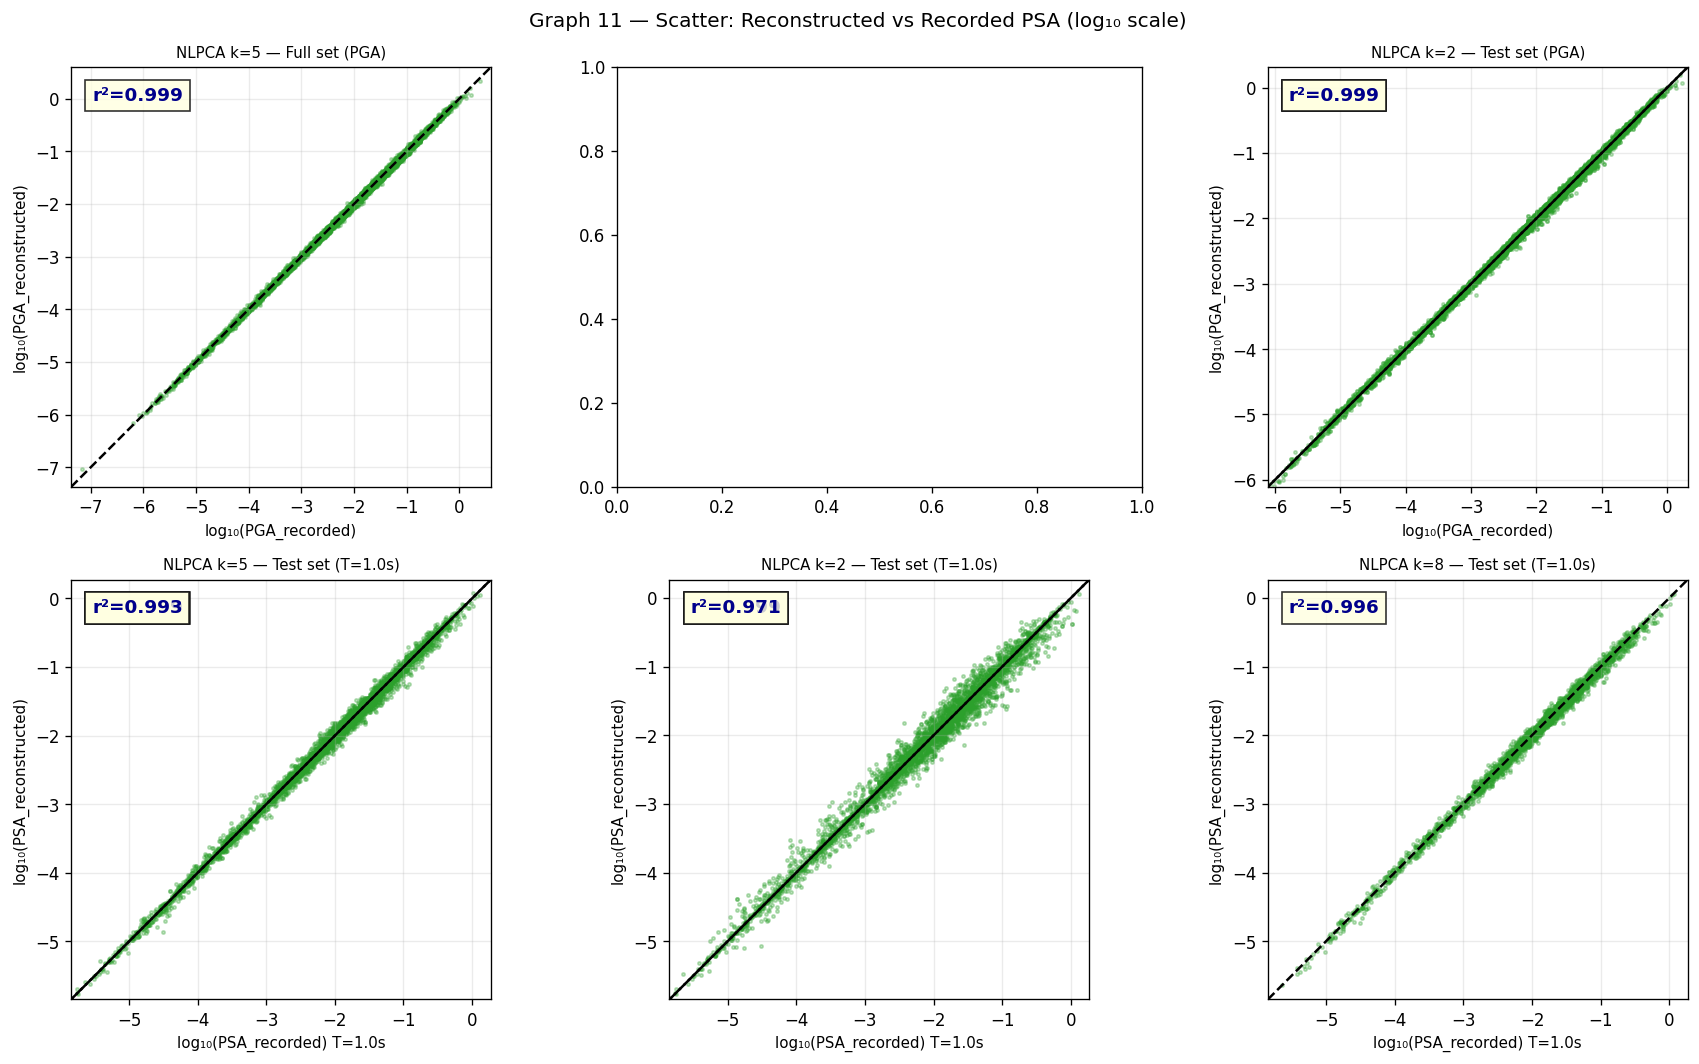

Saved: nlpca_fig11_scatter.png


In [20]:
pga_idx = -1   # PGA is last column in NLPCA targets
pi_1s   = PERIOD_VALUES.index(1.0)  # T=1.0s index

def r2v(yt, yp): return np.corrcoef(yt, yp)[0,1]**2

fig, axes = plt.subplots(2, 3, figsize=(15, 9))
fig.suptitle('Graph 11 — Scatter: Reconstructed vs Recorded PSA (log₁₀ scale)', fontsize=12)

for col, (k, k_label) in enumerate([(BEST_K,'k=5'), (BEST_K,'k=5'), (2,'k=2')]):
    for row, (idx_set, set_name) in enumerate([(np.arange(len(Y_all_s)),'Full'),
                                                (np.arange(len(X_te_nlpca)),'Test')]):
        if col == 1 and row == 0: continue
        ax = axes[row][col] if col < 2 else axes[0][2]

        Y_in = Y_all_s if row==0 else X_te_nlpca
        recon_s = nlpca_models[k].predict(Y_in, verbose=0)
        true_log  = y_scaler.inverse_transform(Y_in)
        recon_log = y_scaler.inverse_transform(recon_s)

        # PGA scatter (log10)
        yt = true_log[:, pga_idx] / np.log(10)
        yp = recon_log[:, pga_idx] / np.log(10)
        r2val = r2v(yt, yp)
        ax.scatter(yt, yp, s=4, alpha=0.3, color='#2ca02c', rasterized=True)
        lim = [min(yt.min(),yp.min())-0.2, max(yt.max(),yp.max())+0.2]
        ax.plot(lim, lim, 'k--', lw=1.5)
        ax.set_xlim(lim); ax.set_ylim(lim); ax.set_aspect('equal')
        ax.text(0.05, 0.92, f'r²={r2val:.3f}', transform=ax.transAxes,
                fontsize=11, fontweight='bold', color='darkblue',
                bbox=dict(fc='lightyellow', alpha=0.8))
        ax.set_xlabel('log₁₀(PGA_recorded)', fontsize=9)
        ax.set_ylabel('log₁₀(PGA_reconstructed)', fontsize=9)
        ax.set_title(f'NLPCA {k_label} — {set_name} set (PGA)', fontsize=9)
        ax.grid(alpha=0.25)

# Bottom row: T=1.0s for different k
for col, k in enumerate([BEST_K, 2, 8]):
    ax = axes[1][col]
    recon_s   = nlpca_models[k].predict(X_te_nlpca, verbose=0)
    true_log  = y_scaler.inverse_transform(X_te_nlpca)
    recon_log = y_scaler.inverse_transform(recon_s)
    yt = true_log[:, pi_1s] / np.log(10)
    yp = recon_log[:, pi_1s] / np.log(10)
    r2val = r2v(yt, yp)
    ax.scatter(yt, yp, s=4, alpha=0.3, color='#2ca02c', rasterized=True)
    lim = [min(yt.min(),yp.min())-0.2, max(yt.max(),yp.max())+0.2]
    ax.plot(lim, lim, 'k--', lw=1.5); ax.set_xlim(lim); ax.set_ylim(lim); ax.set_aspect('equal')
    ax.text(0.05, 0.92, f'r²={r2val:.3f}', transform=ax.transAxes,
            fontsize=11, fontweight='bold', color='darkblue',
            bbox=dict(fc='lightyellow', alpha=0.8))
    ax.set_xlabel('log₁₀(PSA_recorded) T=1.0s', fontsize=9)
    ax.set_ylabel('log₁₀(PSA_reconstructed)', fontsize=9)
    ax.set_title(f'NLPCA k={k} — Test set (T=1.0s)', fontsize=9)
    ax.grid(alpha=0.25)

plt.tight_layout()
plt.savefig('nlpca_fig11_scatter.png')
plt.show()
print("Saved: nlpca_fig11_scatter.png")


## Cell 21 — Graph 12: Reconstruction Error Heatmap (Mw × Rjb Grid)

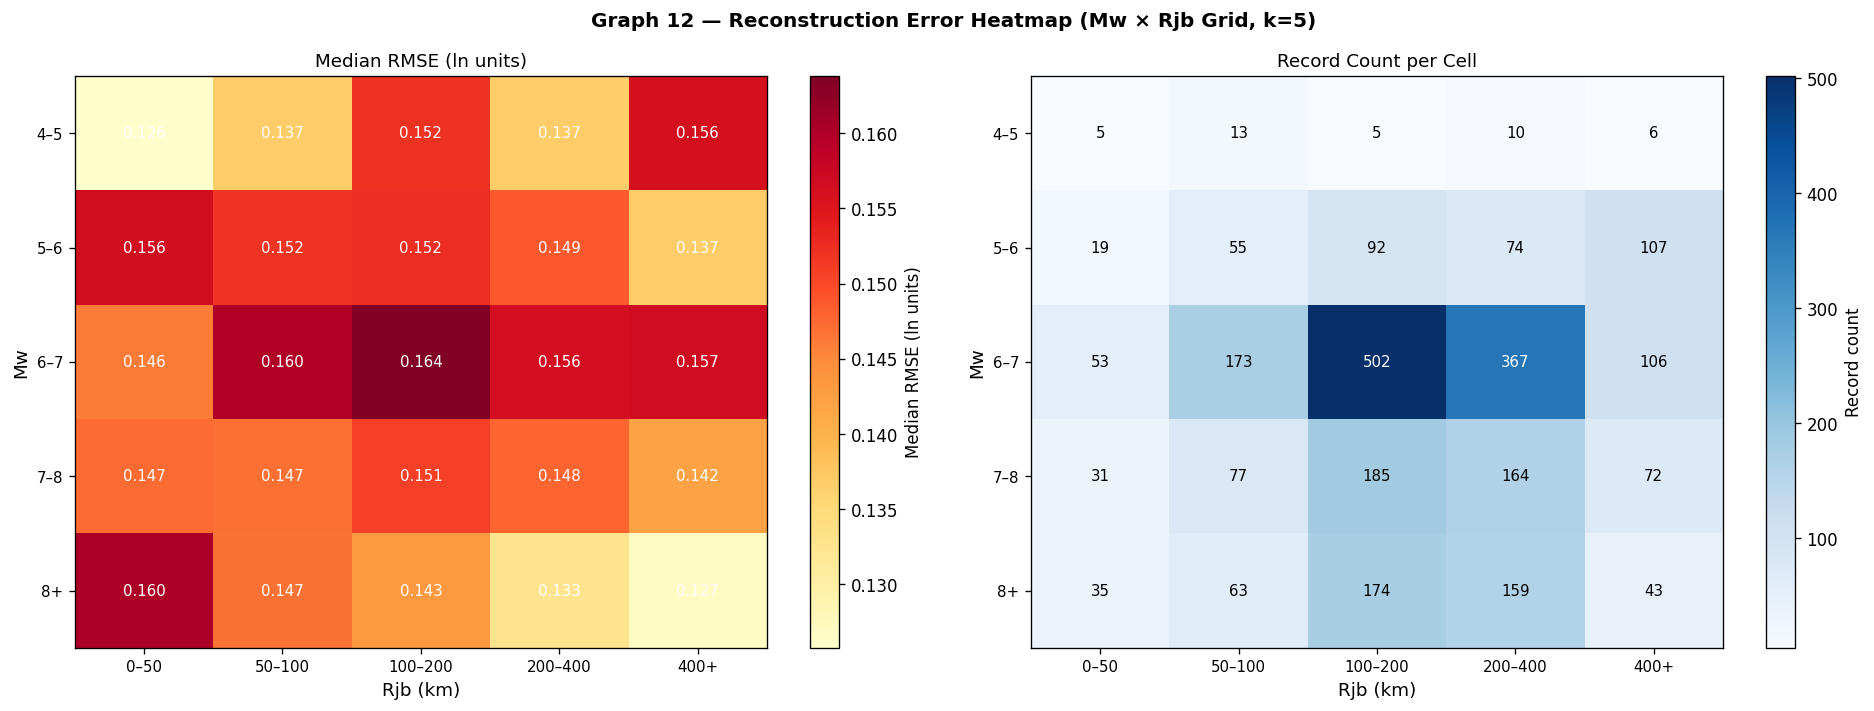

Saved: nlpca_fig12_error_heatmap.png

Interpretation: High RMSE cells = poor reconstruction = sparse training data in that bin.


In [21]:
# Grid of Mw and Rjb bins — show median RMSE per cell
Mw_bins  = np.array([4.0, 5.0, 6.0, 7.0, 8.0, 9.5])
Rjb_bins = np.array([0, 50, 100, 200, 400, 800])
Mw_labels  = ['4–5','5–6','6–7','7–8','8+']
Rjb_labels = ['0–50','50–100','100–200','200–400','400+']

# Per-record RMSE (in ln space, PSA only)
recon_te_s_b = ae_best.predict(X_te_nlpca, verbose=0)
true_log_te  = y_scaler.inverse_transform(X_te_nlpca)
recon_log_te = y_scaler.inverse_transform(recon_te_s_b)
rmse_per_rec = np.sqrt(np.mean((true_log_te[:, :-1] - recon_log_te[:, :-1])**2, axis=1))

grid_rmse  = np.full((len(Mw_labels), len(Rjb_labels)), np.nan)
grid_count = np.zeros_like(grid_rmse)

for i in range(len(Mw_labels)):
    for j in range(len(Rjb_labels)):
        mask = ((MW_te  >= Mw_bins[i])  & (MW_te  < Mw_bins[i+1]) &
                (RJB_te >= Rjb_bins[j]) & (RJB_te < Rjb_bins[j+1]))
        if mask.sum() > 0:
            grid_rmse[i, j]  = np.median(rmse_per_rec[mask])
            grid_count[i, j] = mask.sum()

fig, axes = plt.subplots(1, 2, figsize=(16, 6))
fig.suptitle(f'Graph 12 — Reconstruction Error Heatmap (Mw × Rjb Grid, k={BEST_K})',
             fontsize=12, fontweight='bold')

ax = axes[0]
im = ax.imshow(grid_rmse, aspect='auto', cmap='YlOrRd',
               vmin=np.nanmin(grid_rmse), vmax=np.nanmax(grid_rmse))
plt.colorbar(im, ax=ax, label='Median RMSE (ln units)')
ax.set_xticks(range(len(Rjb_labels))); ax.set_xticklabels(Rjb_labels, fontsize=9)
ax.set_yticks(range(len(Mw_labels)));  ax.set_yticklabels(Mw_labels, fontsize=9)
ax.set_xlabel('Rjb (km)', fontsize=11); ax.set_ylabel('Mw', fontsize=11)
ax.set_title('Median RMSE (ln units)')
for i in range(len(Mw_labels)):
    for j in range(len(Rjb_labels)):
        if not np.isnan(grid_rmse[i, j]):
            ax.text(j, i, f'{grid_rmse[i,j]:.3f}', ha='center', va='center',
                    fontsize=9, color='k' if grid_rmse[i,j] < np.nanmax(grid_rmse)*0.6 else 'w')

ax = axes[1]
im2 = ax.imshow(grid_count, aspect='auto', cmap='Blues')
plt.colorbar(im2, ax=ax, label='Record count')
ax.set_xticks(range(len(Rjb_labels))); ax.set_xticklabels(Rjb_labels, fontsize=9)
ax.set_yticks(range(len(Mw_labels)));  ax.set_yticklabels(Mw_labels, fontsize=9)
ax.set_xlabel('Rjb (km)', fontsize=11); ax.set_ylabel('Mw', fontsize=11)
ax.set_title('Record Count per Cell')
for i in range(len(Mw_labels)):
    for j in range(len(Rjb_labels)):
        ax.text(j, i, f'{int(grid_count[i,j])}', ha='center', va='center',
                fontsize=9, color='k' if grid_count[i,j] < grid_count.max()*0.7 else 'w')

plt.tight_layout()
plt.savefig('nlpca_fig12_error_heatmap.png')
plt.show()
print("Saved: nlpca_fig12_error_heatmap.png")
print()
print("Interpretation: High RMSE cells = poor reconstruction = sparse training data in that bin.")


## Cell 22 — Graph 13: Latent Component Spectral Sensitivity

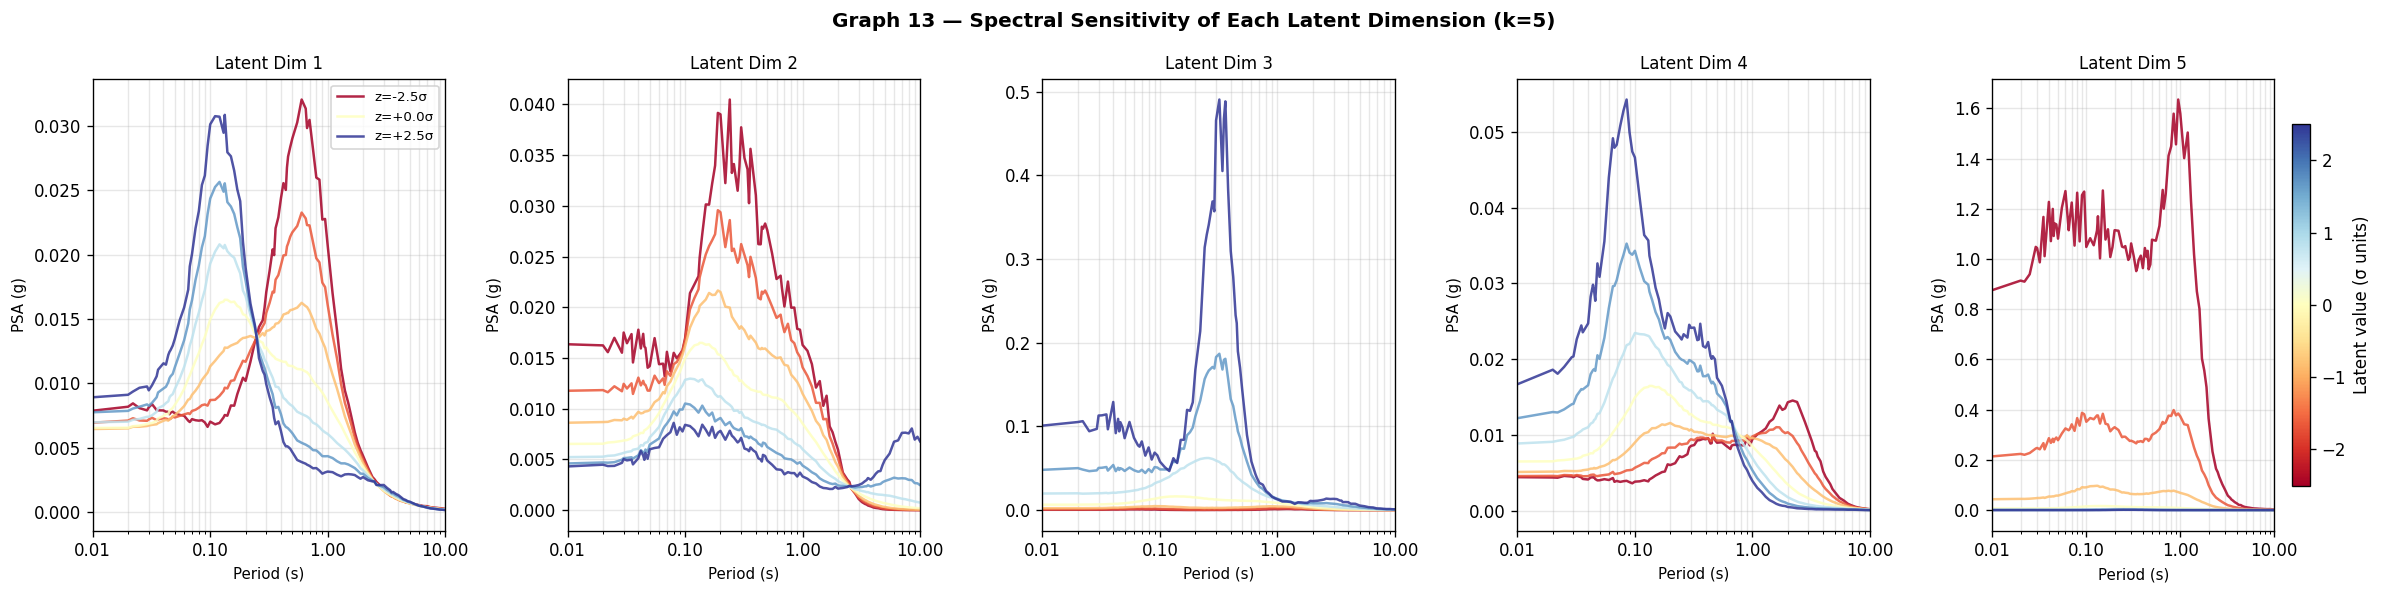

Saved: nlpca_fig13_latent_sensitivity.png

Interpretation:
  Dim 1 = overall amplitude (shifts spectrum up/down)
  Dim 2 = spectral shape (short-period vs long-period dominance)
  Dim 3+ = finer shape variations (peaks, troughs)


In [22]:
# Traverse each latent dimension while holding others at 0
# Shows which part of the spectrum each component controls

latent_mean = latent_all.mean(axis=0)   # (k,)
latent_std  = latent_all.std(axis=0)    # (k,)

fig, axes = plt.subplots(1, BEST_K, figsize=(4*BEST_K, 5))
if BEST_K == 1: axes = [axes]
fig.suptitle(f'Graph 13 — Spectral Sensitivity of Each Latent Dimension (k={BEST_K})',
             fontsize=12, fontweight='bold')

n_steps = 7
alphas = np.linspace(-2.5, 2.5, n_steps)   # ±2.5 sigma range
cmap_lat = plt.cm.RdYlBu(np.linspace(0, 1, n_steps))

for dim_i, ax in enumerate(axes):
    for step_i, alpha in enumerate(alphas):
        z = latent_mean.copy()
        z[dim_i] = latent_mean[dim_i] + alpha * latent_std[dim_i]
        z_tensor = z.reshape(1, -1).astype(np.float32)
        recon_s  = dec_best.predict(z_tensor, verbose=0)
        recon_log = y_scaler.inverse_transform(recon_s)[0]
        psa_vals  = np.exp(recon_log[:-1])   # PSA only

        ax.semilogx(T_psa, psa_vals, color=cmap_lat[step_i],
                    lw=1.5, alpha=0.85,
                    label=f'z={alpha:+.1f}σ' if step_i in [0, n_steps//2, n_steps-1] else '')

    ax.set_xlabel('Period (s)', fontsize=9)
    ax.set_ylabel('PSA (g)', fontsize=9)
    ax.set_title(f'Latent Dim {dim_i+1}', fontsize=10)
    ax.grid(True, which='both', alpha=0.3)
    ax.set_xlim(0.01, 10)
    ax.xaxis.set_major_formatter(ticker.ScalarFormatter())
    if dim_i == 0:
        ax.legend(fontsize=8, loc='upper right')

# Add colorbar
sm = plt.cm.ScalarMappable(cmap='RdYlBu',
                             norm=mcolors.Normalize(vmin=-2.5, vmax=2.5))
sm.set_array([])
fig.colorbar(sm, ax=axes[-1], label='Latent value (σ units)', shrink=0.8)

plt.tight_layout()
plt.savefig('nlpca_fig13_latent_sensitivity.png')
plt.show()
print("Saved: nlpca_fig13_latent_sensitivity.png")
print()
print("Interpretation:")
print("  Dim 1 = overall amplitude (shifts spectrum up/down)")
print("  Dim 2 = spectral shape (short-period vs long-period dominance)")
print("  Dim 3+ = finer shape variations (peaks, troughs)")


## Cell 23 — Save Models & Final Summary

In [23]:
# Save best model
ae_best.save('nlpca_autoencoder_k5.keras')
enc_best.save('nlpca_encoder_k5.keras')
dec_best.save('nlpca_decoder_k5.keras')

with open('nlpca_y_scaler.pkl', 'wb') as f:
    pickle.dump(y_scaler, f)

# Save latent representations
np.save('nlpca_latent_all.npy',   latent_all)
np.save('nlpca_latent_train.npy', enc_best.predict(Y_tr_s, verbose=0))
np.save('nlpca_latent_test.npy',  enc_best.predict(X_te_nlpca, verbose=0))

# Final performance printout
print("=" * 70)
print("  NLPCA — Final Summary (NGA-Sub Dataset)")
print("=" * 70)
print(f"  Dataset         : NGAsub_flatfile_filtered.csv")
print(f"  Records used    : {len(Y_log)}")
print(f"  NLPCA targets   : {n_features} (105 PSA + 1 PGA, all in g)")
print(f"  Architecture    : 106 → [128→64→32] → k → [32→64→128] → 106")
print(f"  Best k (shown)  : {BEST_K}")
print(f"  Train/Test split: 70% / 30%")
print()
print(f"  {'k':>4}   {'Test MSE':>10}   {'Test R²':>10}   {'Mean σ (ln)':>14}")
for k in LATENT_DIMS:
    recon_s   = nlpca_models[k].predict(X_te_nlpca, verbose=0)
    true_log  = y_scaler.inverse_transform(X_te_nlpca)
    recon_log = y_scaler.inverse_transform(recon_s)
    mse_v = mean_squared_error(X_te_nlpca.flatten(), recon_s.flatten())
    r2_v  = r2_score(X_te_nlpca.flatten(), recon_s.flatten())
    sigma_v = (true_log[:, :-1] - recon_log[:, :-1]).std(axis=0).mean()
    star = ' ← best' if k == BEST_K else ''
    print(f"  {k:>4}   {mse_v:>10.5f}   {r2_v:>10.4f}   {sigma_v:>14.4f}{star}")

print()
print("  Saved files:")
files = [
    'nlpca_autoencoder_k5.keras', 'nlpca_encoder_k5.keras', 'nlpca_decoder_k5.keras',
    'nlpca_y_scaler.pkl', 'nlpca_latent_all.npy', 'nlpca_performance_table.csv',
    'nlpca_fig_training_history.png', 'nlpca_fig1_recorded_vs_recon.png',
    'nlpca_fig2_multi_pc_comparison.png', 'nlpca_fig3_mse_vs_pcs.png',
    'nlpca_fig4_scree_pca_comparison.png', 'nlpca_fig5_period_correlation.png',
    'nlpca_fig6_residuals_seismo.png', 'nlpca_fig7_residuals_region.png',
    'nlpca_fig8_sigma_vs_period.png', 'nlpca_fig9_r2_vs_period.png',
    'nlpca_fig10_latent_space.png', 'nlpca_fig11_scatter.png',
    'nlpca_fig12_error_heatmap.png', 'nlpca_fig13_latent_sensitivity.png',
]
for f in files:
    print(f"    ✓  {f}")

print()
print("  HOW TO RELOAD AND USE:")
print("  ae  = keras.models.load_model('nlpca_autoencoder_k5.keras')")
print("  enc = keras.models.load_model('nlpca_encoder_k5.keras')")
print("  dec = keras.models.load_model('nlpca_decoder_k5.keras')")
print("  Y_scaled  = y_scaler.transform(np.log(Y_g))         # normalize")
print("  latent    = enc.predict(Y_scaled)                    # encode")
print("  Y_recon_s = ae.predict(Y_scaled)                     # reconstruct")
print("  Y_recon_g = np.exp(y_scaler.inverse_transform(Y_recon_s))")


  NLPCA — Final Summary (NGA-Sub Dataset)
  Dataset         : NGAsub_flatfile_filtered.csv
  Records used    : 8907
  NLPCA targets   : 106 (105 PSA + 1 PGA, all in g)
  Architecture    : 106 → [128→64→32] → k → [32→64→128] → 106
  Best k (shown)  : 5
  Train/Test split: 70% / 30%

     k     Test MSE      Test R²      Mean σ (ln)
     1      0.07600       0.9215           0.6359
     2      0.01583       0.9837           0.2870
     3      0.00849       0.9912           0.2121
     4      0.00595       0.9939           0.1791
     5      0.00455       0.9953           0.1570 ← best
     6      0.00369       0.9962           0.1421
     7      0.00301       0.9969           0.1285
     8      0.00262       0.9973           0.1204

  Saved files:
    ✓  nlpca_autoencoder_k5.keras
    ✓  nlpca_encoder_k5.keras
    ✓  nlpca_decoder_k5.keras
    ✓  nlpca_y_scaler.pkl
    ✓  nlpca_latent_all.npy
    ✓  nlpca_performance_table.csv
    ✓  nlpca_fig_training_history.png
    ✓  nlpca_fig1_recor